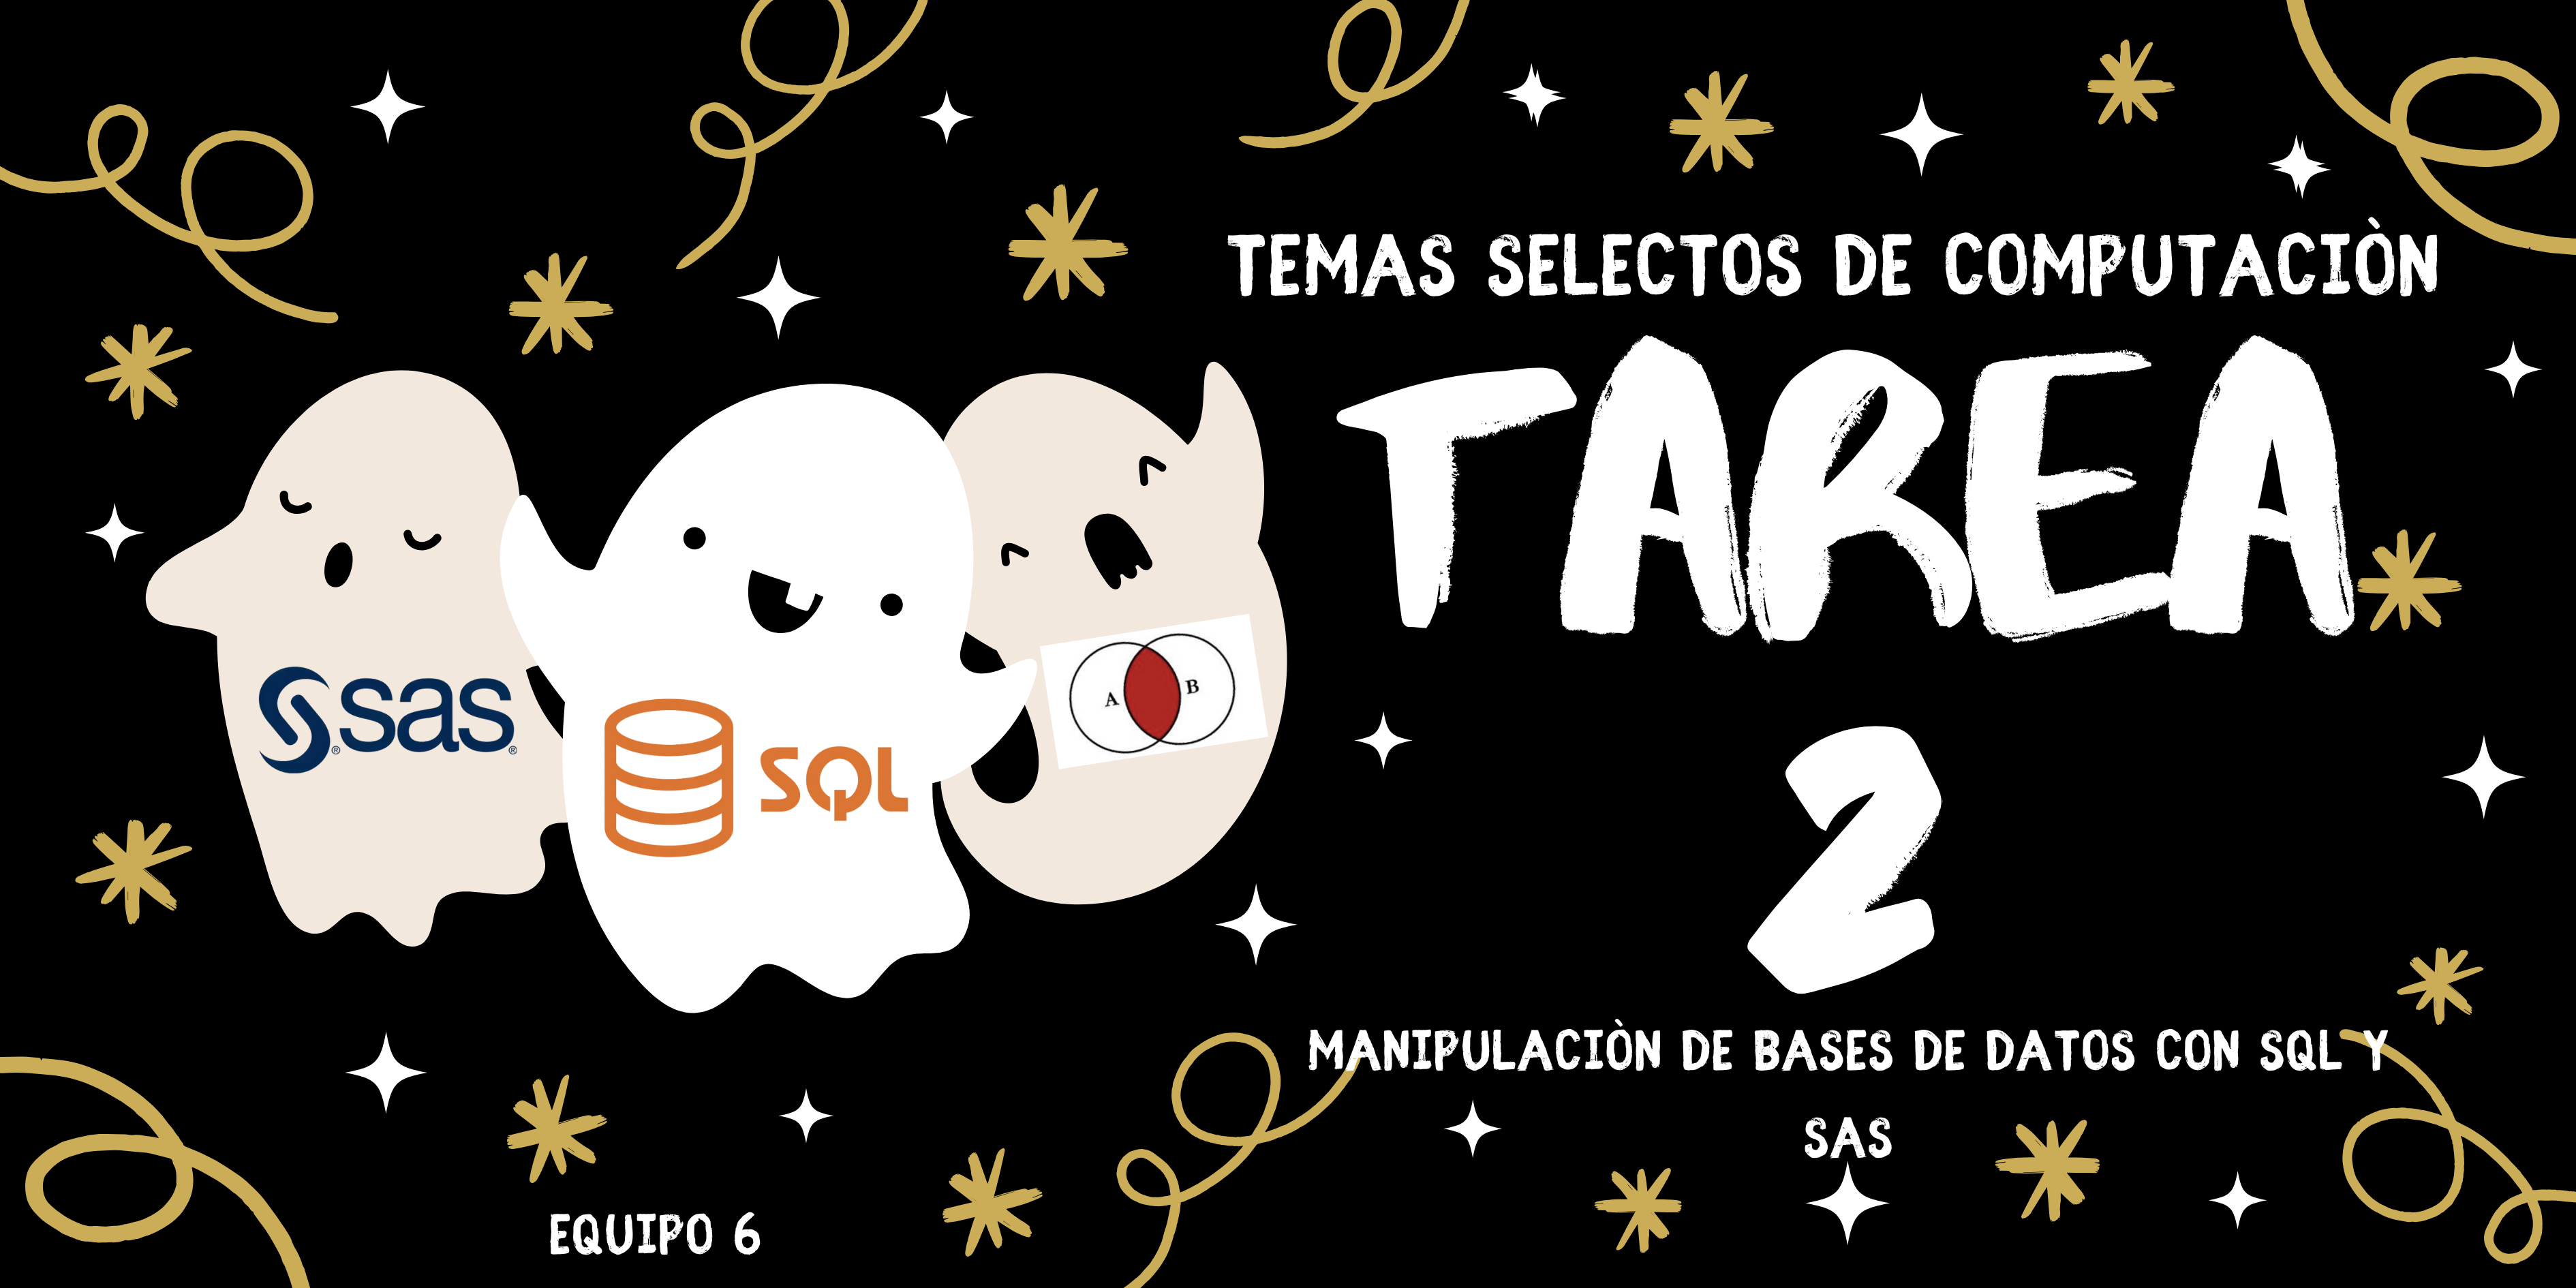



---



## **Integrantes**
* Ascencio Díaz Enrique
* Flores Méndez María de los Ángeles
* García Cruz Elizabeth
* Guzmán Méndez Evelyn
* Hernández Aguilar Víctor Gael
* Martínez Fragoso Esaú
* Mayo Maldonado Emiliano
* Nicolás Hernández Valeria
* Nonato Aguilar Carlos Irving
* Nuñez Rojas Oscar Alberto



---



# **Comentarios del Profesor**
Muy buen trabajo, muy buen esfuerzo en conjunto.

Se cumplieron los objetivos del trabajo sobre una base de datos en ambientes online y uso de protocolos de conexión con las mismas.

Se cumplieron los objetivos de manipulación de información utilizando comandos de SQL y su análisis; utilizando Python y SAS

Se cumplieron los objetivos de análisis y presentación de resultados utlizando las herramientas de python y SAS.

Calificación final 10 de 10.

# Parte 1.
Tomando como referencia el Jupyter Notebook de 1_SQL_2024-I.ipynb para replicar (en Colab) lo visto en clase, deberán seguir los pasos vistos en clase para relacionar dos o más tablas e ingestarlas en una base de datos de SQL Lite, es decir; como se vio en clase deberan utilizar las funciones de insertar datos externos en SQL Lite, generar la unión de tablas y generar reportes. A continuación la descripción de pasos y los requerimientos de la información que deberán buscar en páginas libres.


* Conseguir una base de datos separada en al menos 3 archivos excel o csv (al final de este hilo les dejo referencias para que las consulten)
* Las tablas del punto anterior, deben tener cuando menos 50 registros y no más de 200.
* as tablas deben poderse unir al menos dos de ellas
* Deberan construir al menos una tabla resultante de la union de dos tablas
* Deben construir un repote que ocupe la información de al menos dos tablas
* Deberán realizar al menos 4 consultas a la tabla reporte con las funciones de Like, ">,<,=".
* Presentar sus conclusiones, y de ser posile generen un apoyo visual

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
from pandas import DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
import math


In [ ]:

#Número mínimo de clases para histogramas
def numero_minimo_clases(serie):
    n = len(serie.dropna())
    return max(1, math.ceil(math.log(n) / math.log(2))) if n > 0 else 1

##Subimos la base de datos

In [ ]:
df_appo=pd.read_csv('https://raw.githubusercontent.com/319165515-a11y/temas-selectos-de-compu/refs/heads/main/appointments.csv')
df_billi=pd.read_csv('https://raw.githubusercontent.com/319165515-a11y/temas-selectos-de-compu/refs/heads/main/billing.csv')
df_doc=pd.read_csv('https://raw.githubusercontent.com/319165515-a11y/temas-selectos-de-compu/refs/heads/main/doctors.csv')
df_pac=pd.read_csv('https://raw.githubusercontent.com/319165515-a11y/temas-selectos-de-compu/refs/heads/main/patients.csv')
df_trat=pd.read_csv('https://raw.githubusercontent.com/319165515-a11y/temas-selectos-de-compu/refs/heads/main/treatments.csv')

In [ ]:

def estilo_tablas(df):
    # Paleta "rocket" de Seaborn (mismo gradiente que tu gráfico)
    palette = sns.color_palette("rocket", n_colors=len(df.columns)).as_hex()

    # Definimos estilos base oscuros
    estilos = [
        {"selector": "table", "props": [
            ("border-collapse", "collapse"),
            ("background-color", "#0e1117"),
            ("border", "2px solid #2b2b2b"),
            ("color", "white")
        ]},
        {"selector": "th", "props": [
            ("background-color", "#1e1e1e"),
            ("color", "white"),
            ("font-size", "14px"),
            ("text-align", "center"),
            ("border", "1px solid #444444"),
            ("font-family", "'DejaVu Sans', sans-serif")
        ]},
        {"selector": "td", "props": [
            ("text-align", "center"),
            ("border", "1px solid #333333"),
            ("font-family", "'DejaVu Sans', sans-serif"),
            ("color", "#e6e6e6"),
            ("padding", "6px")
        ]}
    ]

    # Aplicamos un color distinto a cada columna según la paleta
    df_styled = df.style.set_table_styles(estilos)
    for i, col in enumerate(df.columns):
        df_styled = df_styled.set_properties(
            subset=[col],
            **{"background-color": palette[i]}
        )

    return df_styled


In [ ]:
estilo_tablas(df_appo.head())

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


/tmp/ipython-input-932156060.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='status', data=df_appo, ax=axes[0,0], palette=palette)
/tmp/ipython-input-932156060.py:34: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.countplot(x='status', data=df_appo, ax=axes[0,0], palette=palette)
/tmp/ipython-input-932156060.py:68: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.countplot(data=df_appo, x='reason_for_visit', hue='status', ax=axes[1,1], palette=palette)
/tmp/ipython-input-932156060.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='appointment_time', data=df_app

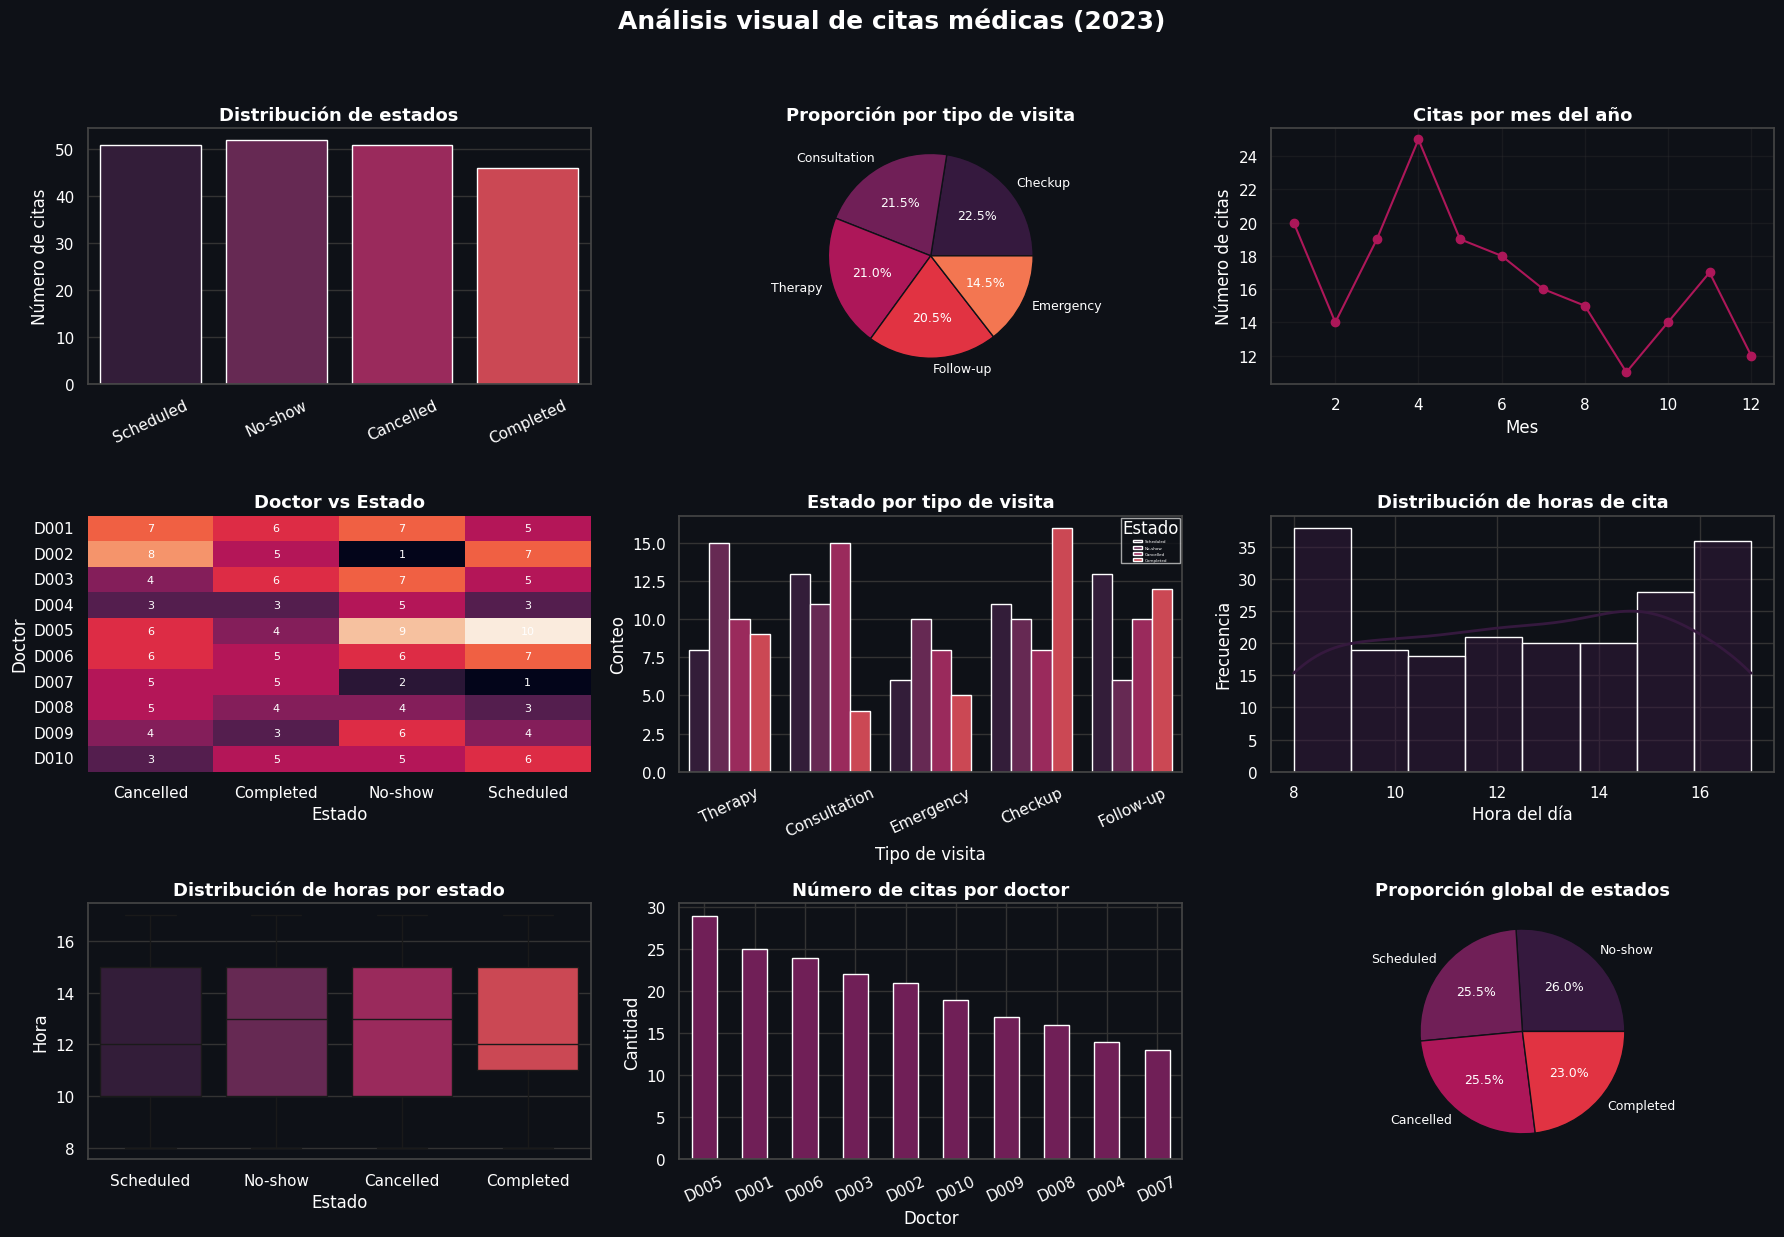

In [ ]:
#Tratamiento datos
df_appo['appointment_date'] = pd.to_datetime(df_appo['appointment_date'], errors='coerce')
df_appo['month'] = df_appo['appointment_date'].dt.month
df_appo['appointment_time'] = pd.to_numeric(df_appo['appointment_time'].astype(str).str.split(':').str[0], errors='coerce')

#Número mínimo de clases para histogramas
clases_hora = numero_minimo_clases(df_appo['appointment_time'].dropna())

#Estilo oscuro
plt.style.use('dark_background')
palette = sns.color_palette('rocket')
sns.set(style='darkgrid', palette=palette)

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

#Figura principal
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Análisis visual de citas médicas (2023)',
             fontsize=18, weight='bold', color='white', y=1.03)

#Distribución de estados
sns.countplot(x='status', data=df_appo, ax=axes[0,0], palette=palette)
axes[0,0].set_title('Distribución de estados')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Número de citas')
axes[0,0].tick_params(axis='x', rotation=25)

#Razones de visita
top_reasons = df_appo['reason_for_visit'].value_counts().nlargest(6)
top_reasons.plot.pie(
    ax=axes[0,1],
    autopct='%1.1f%%',
    colors=palette[:len(top_reasons)],
    textprops={'color': 'white', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0e1117'}
)
axes[0,1].set_title('Proporción por tipo de visita')
axes[0,1].set_ylabel('')

#Citas por mes
df_appo.groupby('month').size().sort_index().plot(marker='o', color=palette[2], ax=axes[0,2])
axes[0,2].set_title('Citas por mes del año')
axes[0,2].set_xlabel('Mes')
axes[0,2].set_ylabel('Número de citas')
axes[0,2].grid(True, alpha=0.3)

#Doctor vs Estado
pivot1 = pd.crosstab(df_appo['doctor_id'], df_appo['status'])
sns.heatmap(pivot1, annot=True, cmap='rocket', fmt='d', ax=axes[1,0],
            cbar=False, annot_kws={'color':'white', 'fontsize':8})
axes[1,0].set_title('Doctor vs Estado')
axes[1,0].set_xlabel('Estado')
axes[1,0].set_ylabel('Doctor')

#Estado por tipo de visita
sns.countplot(data=df_appo, x='reason_for_visit', hue='status', ax=axes[1,1], palette=palette)
axes[1,1].set_title('Estado por tipo de visita')
axes[1,1].set_xlabel('Tipo de visita')
axes[1,1].set_ylabel('Conteo')
axes[1,1].legend(title='Estado', loc='upper right', fontsize=3, labelcolor='white')
axes[1,1].tick_params(axis='x', rotation=25)

#Histograma de horas de cita
sns.histplot(
    df_appo['appointment_time'].dropna(),
    bins=clases_hora,
    kde=True,
    color=palette[0],
    line_kws={'color': palette[3], 'linewidth': 2},
    ax=axes[1,2]
)
axes[1,2].set_title('Distribución de horas de cita')
axes[1,2].set_xlabel('Hora del día')
axes[1,2].set_ylabel('Frecuencia')

#Boxplot de horas por estado
sns.boxplot(x='status', y='appointment_time', data=df_appo, ax=axes[2,0], palette=palette)
axes[2,0].set_title('Distribución de horas por estado')
axes[2,0].set_xlabel('Estado')
axes[2,0].set_ylabel('Hora')

#Citas por doctor
df_appo['doctor_id'].value_counts().plot(kind='bar', color=palette[1], ax=axes[2,1])
axes[2,1].set_title('Número de citas por doctor')
axes[2,1].set_xlabel('Doctor')
axes[2,1].set_ylabel('Cantidad')
axes[2,1].tick_params(axis='x', rotation=25)

#Proporción de estados (pie global)
status_counts = df_appo['status'].value_counts()
status_counts.plot.pie(
    ax=axes[2,2],
    autopct='%1.1f%%',
    colors=palette[:len(status_counts)],
    textprops={'color': 'white', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0e1117'}
)
axes[2,2].set_title('Proporción global de estados')
axes[2,2].set_ylabel('')

#Ajuste de graficos
plt.tight_layout()
plt.subplots_adjust()
plt.show()

In [ ]:
estilo_tablas(df_billi.head())

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status
0,B001,P034,T001,2023-08-09,3941.970000,Insurance,Pending
1,B002,P032,T002,2023-06-09,4158.440000,Insurance,Paid
2,B003,P048,T003,2023-06-28,3731.550000,Insurance,Paid
3,B004,P025,T004,2023-09-01,4799.860000,Insurance,Failed
4,B005,P040,T005,2023-07-06,582.050000,Credit Card,Pending


/tmp/ipython-input-671309353.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='payment_status', data=df_billi, ax=axes[0,0], palette=palette)
/tmp/ipython-input-671309353.py:32: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(x='payment_status', data=df_billi, ax=axes[0,0], palette=palette)
/tmp/ipython-input-671309353.py:66: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(data=df_billi, x='payment_method', hue='payment_status', ax=axes[1,1], palette=palette)
/tmp/ipython-input-671309353.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='payment_status', 

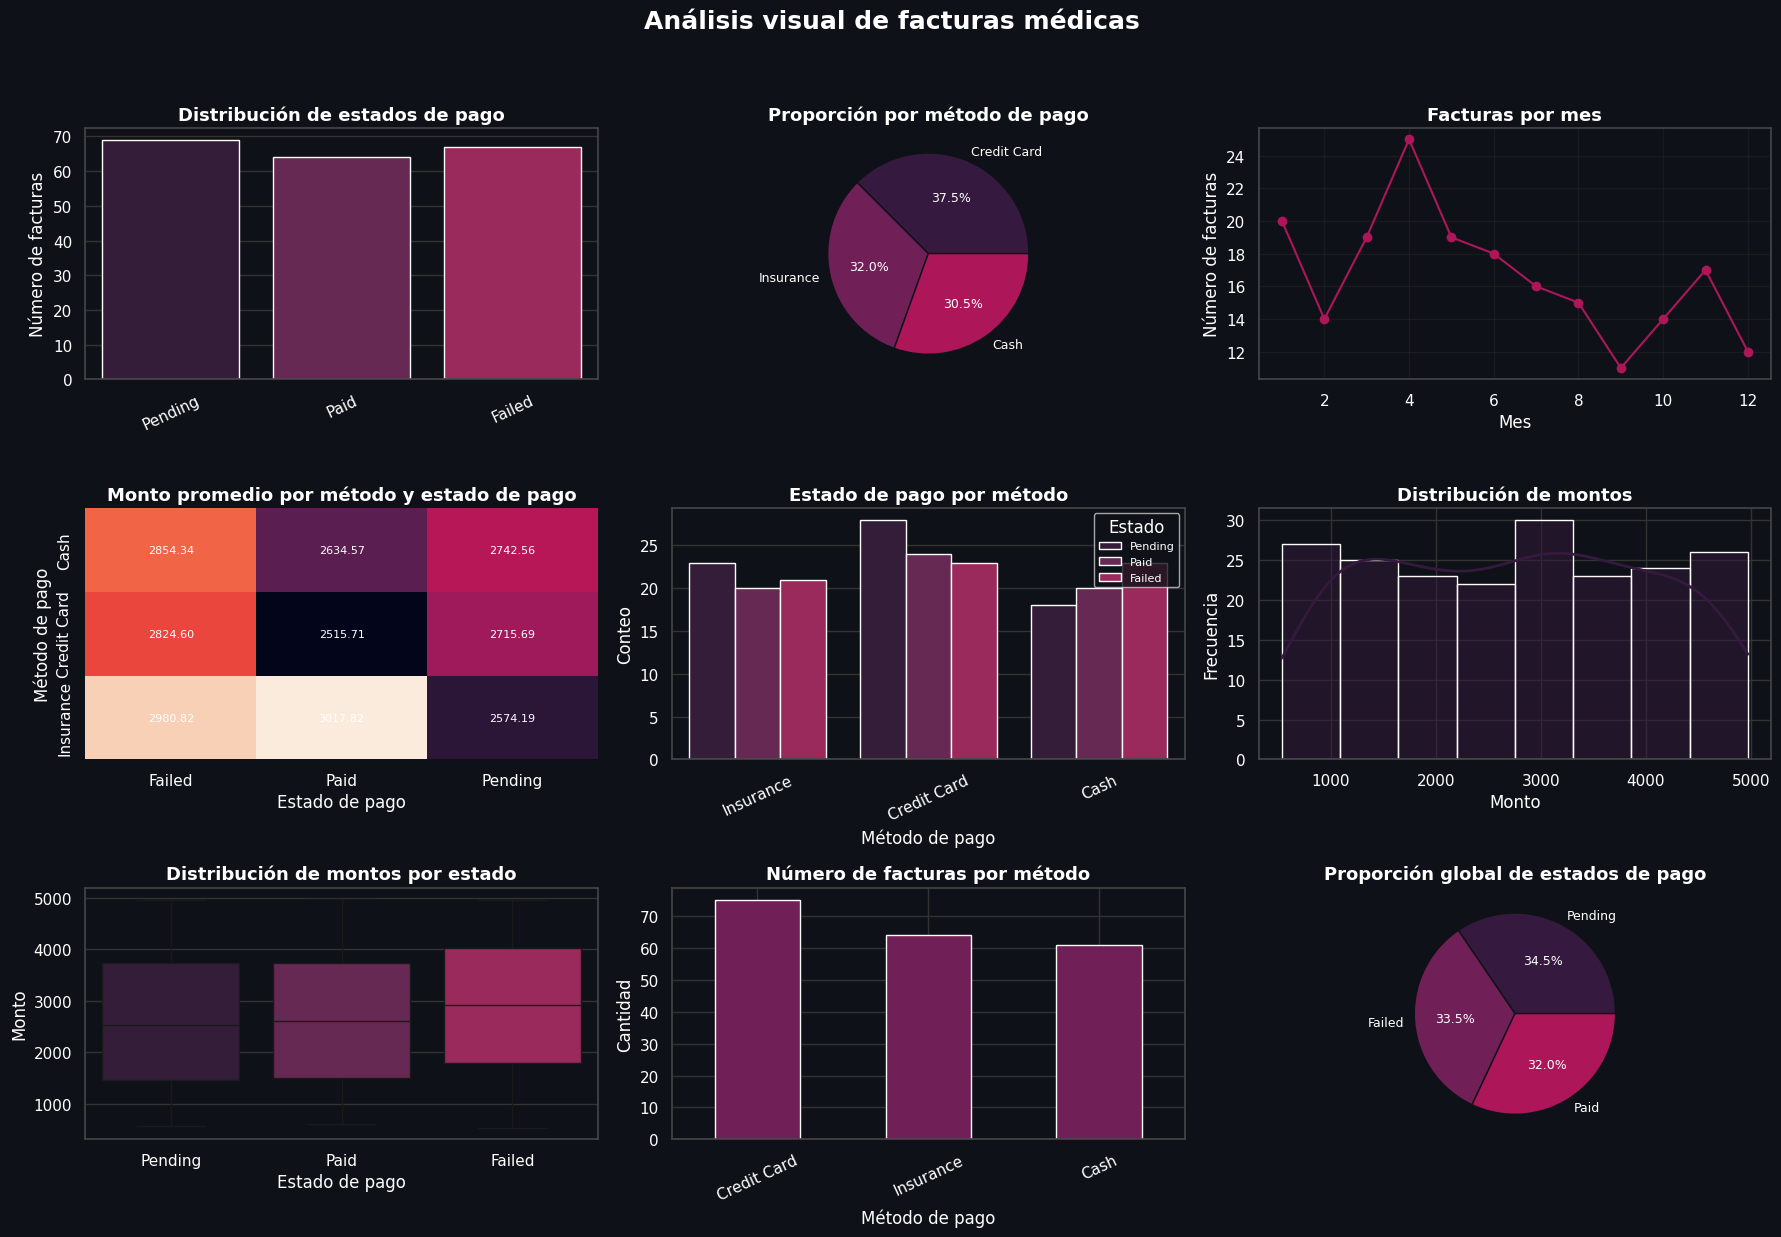

In [ ]:
#Tratamiento datos
df_billi['bill_date'] = pd.to_datetime(df_billi['bill_date'], errors='coerce')
df_billi['month'] = df_billi['bill_date'].dt.month
df_billi['year'] = df_billi['bill_date'].dt.year
#Número mínimo de clases para histogramas
clases_amount = numero_minimo_clases(df_billi['amount'].dropna())
#Estilo oscuro
plt.style.use('dark_background')
palette = sns.color_palette('rocket')
sns.set(style='darkgrid', palette=palette)

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

#Figura principal
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Análisis visual de facturas médicas',
             fontsize=18, weight='bold', color='white', y=1.03)

#Distribución de estados de pago
sns.countplot(x='payment_status', data=df_billi, ax=axes[0,0], palette=palette)
axes[0,0].set_title('Distribución de estados de pago')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Número de facturas')
axes[0,0].tick_params(axis='x', rotation=25)

#Metodos de pago
top_methods = df_billi['payment_method'].value_counts()
top_methods.plot.pie(
    ax=axes[0,1],
    autopct='%1.1f%%',
    colors=palette[:len(top_methods)],
    textprops={'color': 'white', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0e1117'}
)
axes[0,1].set_title('Proporción por método de pago')
axes[0,1].set_ylabel('')

# Facturas por mes
df_billi.groupby('month').size().sort_index().plot(marker='o', color=palette[2], ax=axes[0,2])
axes[0,2].set_title('Facturas por mes')
axes[0,2].set_xlabel('Mes')
axes[0,2].set_ylabel('Número de facturas')
axes[0,2].grid(True, alpha=0.3)

#Monto por estado de pago
pivot_amt = df_billi.pivot_table(index='payment_method', columns='payment_status', values='amount', aggfunc='mean')
sns.heatmap(pivot_amt, annot=True, fmt=".2f", cmap='rocket', ax=axes[1,0],
            cbar=False, annot_kws={'color':'white', 'fontsize':8})
axes[1,0].set_title('Monto promedio por método y estado de pago')
axes[1,0].set_xlabel('Estado de pago')
axes[1,0].set_ylabel('Método de pago')

#Estado de pago por método
sns.countplot(data=df_billi, x='payment_method', hue='payment_status', ax=axes[1,1], palette=palette)
axes[1,1].set_title('Estado de pago por método')
axes[1,1].set_xlabel('Método de pago')
axes[1,1].set_ylabel('Conteo')
axes[1,1].legend(title='Estado', loc='upper right', fontsize=8, labelcolor='white')
axes[1,1].tick_params(axis='x', rotation=25)

#Histograma de montos con KDE
bar_color = palette[0]
kde_color = palette[3]
sns.histplot(
    df_billi['amount'].dropna(),
    bins=clases_amount,
    kde=True,
    color=bar_color,
    line_kws={'color': kde_color, 'linewidth': 2},
    ax=axes[1,2]
)
axes[1,2].set_title('Distribución de montos')
axes[1,2].set_xlabel('Monto')
axes[1,2].set_ylabel('Frecuencia')

#Boxplot de montos por estado de pago
sns.boxplot(x='payment_status', y='amount', data=df_billi, ax=axes[2,0], palette=palette)
axes[2,0].set_title('Distribución de montos por estado')
axes[2,0].set_xlabel('Estado de pago')
axes[2,0].set_ylabel('Monto')

#Facturas por método
df_billi['payment_method'].value_counts().plot(kind='bar', color=palette[1], ax=axes[2,1])
axes[2,1].set_title('Número de facturas por método')
axes[2,1].set_xlabel('Método de pago')
axes[2,1].set_ylabel('Cantidad')
axes[2,1].tick_params(axis='x', rotation=25)

#Proporción de estados de pago
status_counts = df_billi['payment_status'].value_counts()
status_counts.plot.pie(
    ax=axes[2,2],
    autopct='%1.1f%%',
    colors=palette[:len(status_counts)],
    textprops={'color': 'white', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0e1117'}
)
axes[2,2].set_title('Proporción global de estados de pago')
axes[2,2].set_ylabel('')

#Ajustes finales
plt.tight_layout()
plt.subplots_adjust()
plt.show()


In [ ]:
estilo_tablas(df_trat.head())

,treatment_id,appointment_id,treatment_type,description,cost,treatment_date
0,T001,A001,Chemotherapy,Basic screening,3941.970000,2023-08-09
1,T002,A002,MRI,Advanced protocol,4158.440000,2023-06-09
2,T003,A003,MRI,Standard procedure,3731.550000,2023-06-28
3,T004,A004,MRI,Basic screening,4799.860000,2023-09-01
4,T005,A005,ECG,Standard procedure,582.050000,2023-07-06


/tmp/ipython-input-3902371290.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='treatment_type', data=df_trat, ax=axes[0,0], palette=palette)
/tmp/ipython-input-3902371290.py:34: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.countplot(x='treatment_type', data=df_trat, ax=axes[0,0], palette=palette)
/tmp/ipython-input-3902371290.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_trat, x='treatment_type', ax=axes[1,1], palette=palette)
/tmp/ipython-input-3902371290.py:68: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.countplot(data=df_trat, x='treatment_type', ax=ax

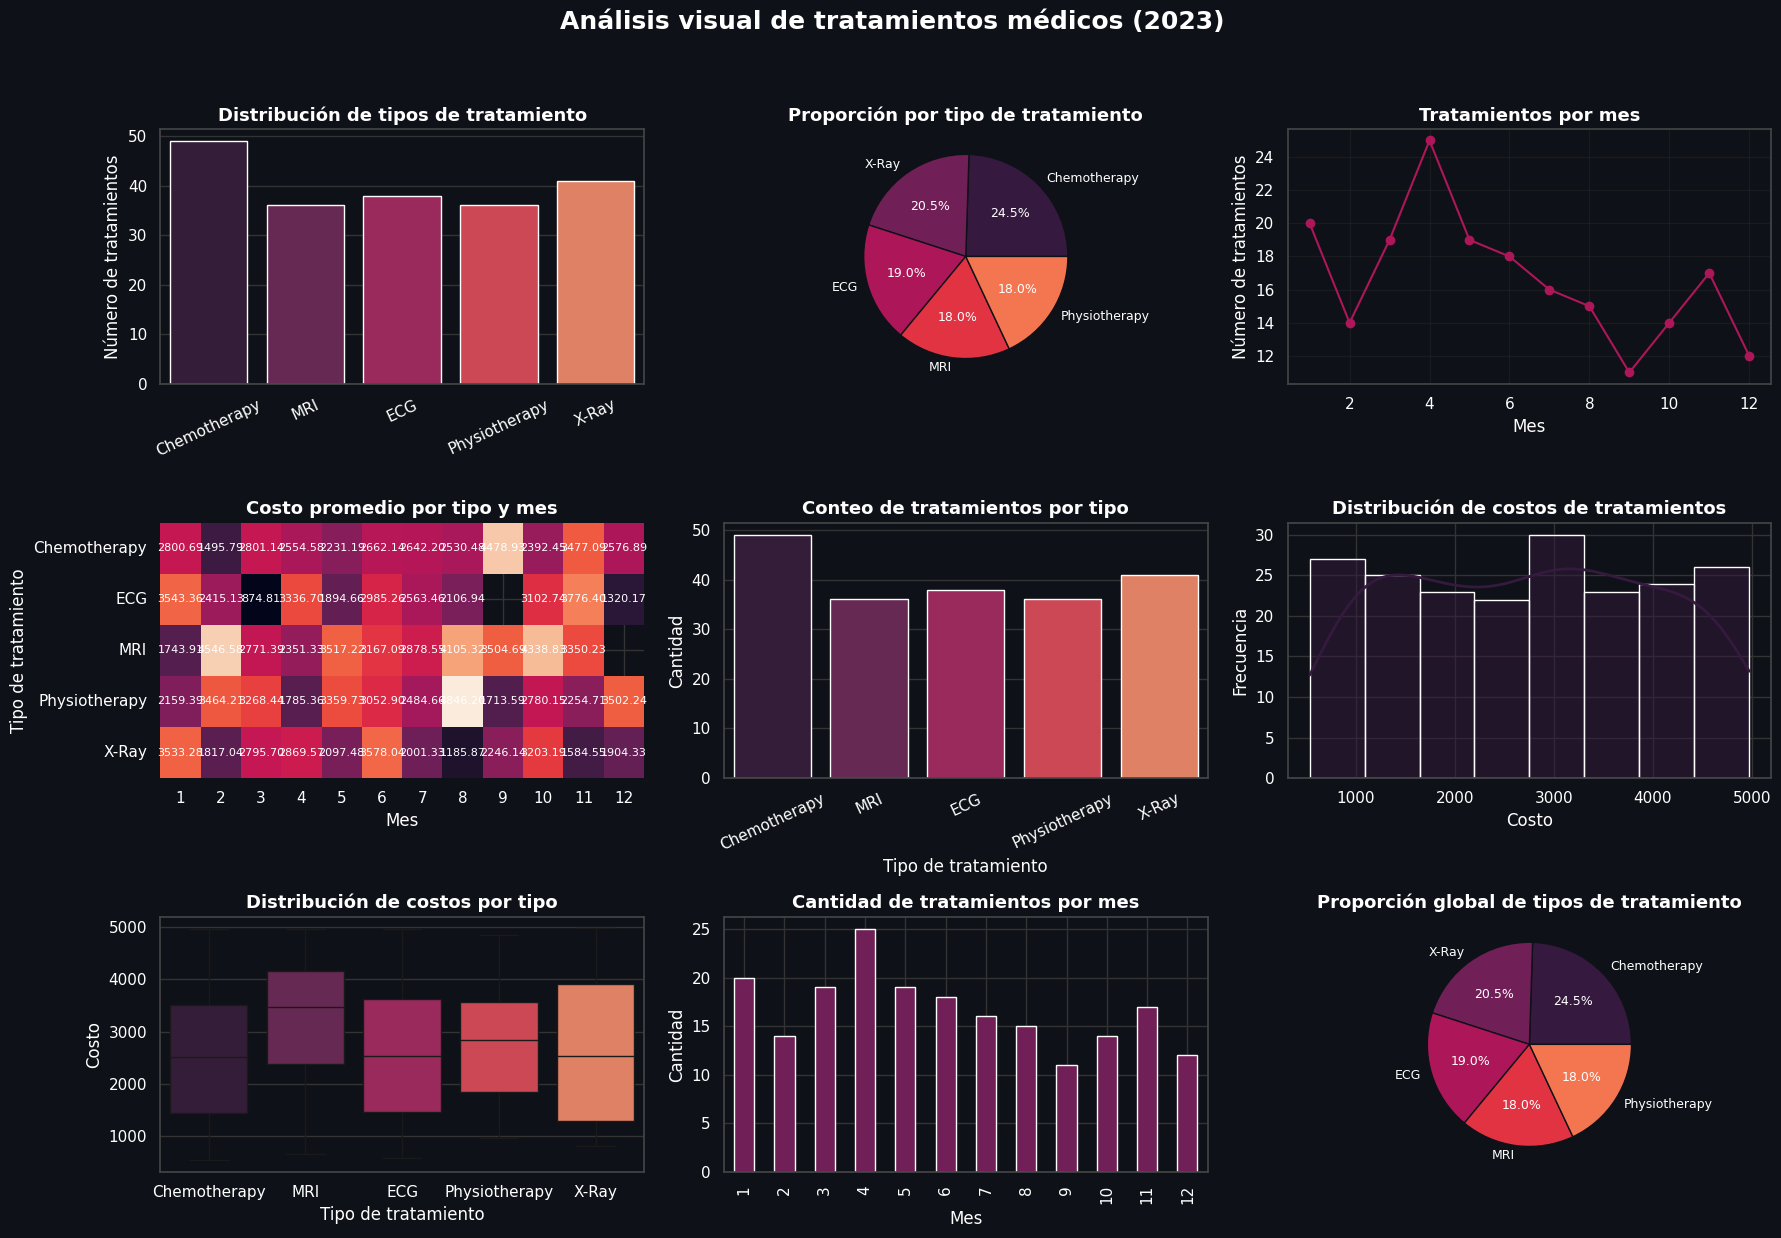

In [ ]:
#Tratamiento datos
df_trat['treatment_date'] = pd.to_datetime(df_trat['treatment_date'], errors='coerce')
df_trat['treatment_month'] = df_trat['treatment_date'].dt.month
df_trat['treatment_year'] = df_trat['treatment_date'].dt.year

#Número mínimo de clases para histogramas
clases_cost = numero_minimo_clases(df_trat['cost'].dropna())

#Estilo oscuro
plt.style.use('dark_background')
palette = sns.color_palette('rocket')
sns.set(style='darkgrid', palette=palette)

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

#Figura principal
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Análisis visual de tratamientos médicos (2023)',
             fontsize=18, weight='bold', color='white', y=1.03)

#Distribución de tipos de tratamiento
sns.countplot(x='treatment_type', data=df_trat, ax=axes[0,0], palette=palette)
axes[0,0].set_title('Distribución de tipos de tratamiento')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Número de tratamientos')
axes[0,0].tick_params(axis='x', rotation=25)

#Distribución de tratamientos
top_types = df_trat['treatment_type'].value_counts()
top_types.plot.pie(
    ax=axes[0,1],
    autopct='%1.1f%%',
    colors=palette[:len(top_types)],
    textprops={'color': 'white', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0e1117'}
)
axes[0,1].set_title('Proporción por tipo de tratamiento')
axes[0,1].set_ylabel('')

#Tratamientos por mes
df_trat.groupby('treatment_month').size().sort_index().plot(marker='o', color=palette[2], ax=axes[0,2])
axes[0,2].set_title('Tratamientos por mes')
axes[0,2].set_xlabel('Mes')
axes[0,2].set_ylabel('Número de tratamientos')
axes[0,2].grid(True, alpha=0.3)

#Costo promedio por tipo de tratamiento
pivot_cost = df_trat.pivot_table(index='treatment_type', columns='treatment_month', values='cost', aggfunc='mean')
sns.heatmap(pivot_cost, annot=True, fmt=".2f", cmap='rocket', ax=axes[1,0],
            cbar=False, annot_kws={'color':'white', 'fontsize':8})
axes[1,0].set_title('Costo promedio por tipo y mes')
axes[1,0].set_xlabel('Mes')
axes[1,0].set_ylabel('Tipo de tratamiento')

#Conteo de tratamientos por tipo
sns.countplot(data=df_trat, x='treatment_type', ax=axes[1,1], palette=palette)
axes[1,1].set_title('Conteo de tratamientos por tipo')
axes[1,1].set_xlabel('Tipo de tratamiento')
axes[1,1].set_ylabel('Cantidad')
axes[1,1].tick_params(axis='x', rotation=25)

#Histograma de costos con KDE
bar_color = palette[0]
kde_color = palette[3]
sns.histplot(
    df_trat['cost'].dropna(),
    bins=clases_cost,
    kde=True,
    color=bar_color,
    line_kws={'color': kde_color, 'linewidth': 2},
    ax=axes[1,2]
)
axes[1,2].set_title('Distribución de costos de tratamientos')
axes[1,2].set_xlabel('Costo')
axes[1,2].set_ylabel('Frecuencia')

#Boxplot de costos por tipo de tratamiento
sns.boxplot(x='treatment_type', y='cost', data=df_trat, ax=axes[2,0], palette=palette)
axes[2,0].set_title('Distribución de costos por tipo')
axes[2,0].set_xlabel('Tipo de tratamiento')
axes[2,0].set_ylabel('Costo')

#Cantidad de tratamientos por mes
df_trat['treatment_month'].value_counts().sort_index().plot(kind='bar', color=palette[1], ax=axes[2,1])
axes[2,1].set_title('Cantidad de tratamientos por mes')
axes[2,1].set_xlabel('Mes')
axes[2,1].set_ylabel('Cantidad')

#Proporción de tipos de tratamiento
type_counts = df_trat['treatment_type'].value_counts()
type_counts.plot.pie(
    ax=axes[2,2],
    autopct='%1.1f%%',
    colors=palette[:len(type_counts)],
    textprops={'color': 'white', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0e1117'}
)
axes[2,2].set_title('Proporción global de tipos de tratamiento')
axes[2,2].set_ylabel('')

#Ajustes finales
plt.tight_layout()
plt.subplots_adjust()
plt.show()

In [ ]:
estilo_tablas(df_doc)

,doctor_id,first_name,last_name,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com
5,D006,Alex,Davis,Pediatrics,6570137231,23,Central Hospital,dr.alex.davis@hospital.com
6,D007,Robert,Davis,Oncology,8217493115,26,Westside Clinic,dr.robert.davis@hospital.com
7,D008,Linda,Brown,Dermatology,9069162601,5,Westside Clinic,dr.linda.brown@hospital.com
8,D009,Sarah,Smith,Pediatrics,7387087517,26,Central Hospital,dr.sarah.smith@hospital.com
9,D010,Linda,Wilson,Oncology,6176383634,21,Eastside Clinic,dr.linda.wilson@hospital.com


/tmp/ipython-input-568677000.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='specialization', data=df_doc, ax=axes[0,0], palette=palette)
/tmp/ipython-input-568677000.py:28: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(x='specialization', data=df_doc, ax=axes[0,0], palette=palette)
/tmp/ipython-input-568677000.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='specialization', y='years_experience', data=exp_mean, palette=palette, ax=axes[0,1])
/tmp/ipython-input-568677000.py:36: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.barplot(x='specialization', y='yea

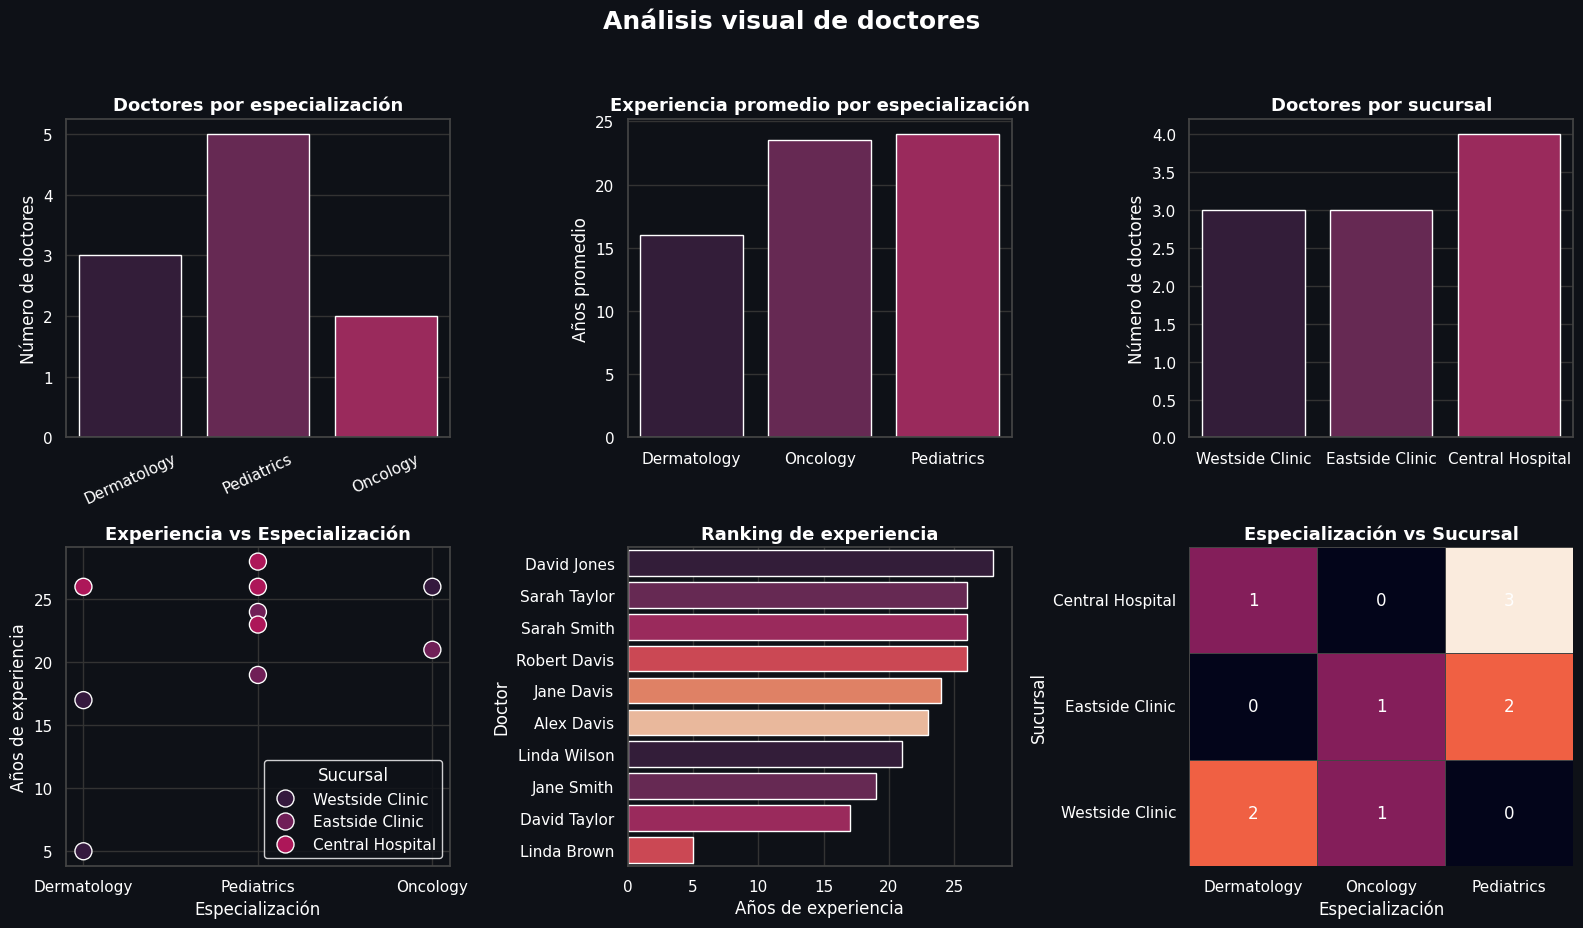

In [ ]:
# Preprocesamiento
df_doc['full_name'] = df_doc['first_name'] + ' ' + df_doc['last_name']

# Estilo oscuro y paleta global
plt.style.use('dark_background')
palette = sns.color_palette('rocket')
sns.set(style='darkgrid', palette=palette)

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

# Crear figura
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Análisis visual de doctores', fontsize=18, weight='bold', color='white', y=1.03)

# 1. Número de doctores por especialización
sns.countplot(x='specialization', data=df_doc, ax=axes[0,0], palette=palette)
axes[0,0].set_title('Doctores por especialización')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Número de doctores')
axes[0,0].tick_params(axis='x', rotation=25)

# 2. Experiencia promedio por especialización
exp_mean = df_doc.groupby('specialization')['years_experience'].mean().reset_index()
sns.barplot(x='specialization', y='years_experience', data=exp_mean, palette=palette, ax=axes[0,1])
axes[0,1].set_title('Experiencia promedio por especialización')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('Años promedio')

# 3. Distribución de doctores por sucursal
sns.countplot(x='hospital_branch', data=df_doc, ax=axes[0,2], palette=palette)
axes[0,2].set_title('Doctores por sucursal')
axes[0,2].set_xlabel('')
axes[0,2].set_ylabel('Número de doctores')

# 4. Experiencia vs especialización (scatterplot)
sns.scatterplot(x='specialization', y='years_experience', data=df_doc,
                hue='hospital_branch', palette=palette, s=150, ax=axes[1,0])
axes[1,0].set_title('Experiencia vs Especialización')
axes[1,0].set_xlabel('Especialización')
axes[1,0].set_ylabel('Años de experiencia')
axes[1,0].legend(title='Sucursal', facecolor='#0e1117', edgecolor='white', labelcolor='white')

# 5. Ranking de años de experiencia
top_exp = df_doc.sort_values('years_experience', ascending=False)
sns.barplot(x='years_experience', y='full_name', data=top_exp, palette=palette, ax=axes[1,1])
axes[1,1].set_title('Ranking de experiencia')
axes[1,1].set_xlabel('Años de experiencia')
axes[1,1].set_ylabel('Doctor')

# 6. Especialización vs sucursal (heatmap)
pivot = pd.crosstab(df_doc['hospital_branch'], df_doc['specialization'])
sns.heatmap(pivot, annot=True, fmt='d', cmap='rocket', cbar=False, ax=axes[1,2],
            annot_kws={'color':'white'}, linewidths=0.5, linecolor='#444444')
axes[1,2].set_title('Especialización vs Sucursal')
axes[1,2].set_xlabel('Especialización')
axes[1,2].set_ylabel('Sucursal')
axes[1,2].set_facecolor('#0e1117')

# Ajustes finales
plt.tight_layout()
plt.show()


In [ ]:
estilo_tablas(df_pac)

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com
5,P006,Linda,Jones,M,1963-06-16,7561777264,321 Maple Dr,2022-10-02,HealthIndia,INS613758,linda.jones@mail.com
6,P007,Alex,Johnson,F,1989-06-08,6278710077,789 Pine Rd,2021-12-25,MedCare Plus,INS465890,alex.johnson@mail.com
7,P008,David,Davis,F,1976-07-05,7090558393,456 Oak Ave,2021-05-25,WellnessCorp,INS545101,david.davis@mail.com
8,P009,Laura,Davis,M,1971-12-11,7060324619,321 Maple Dr,2022-09-18,PulseSecure,INS136631,laura.davis@mail.com
9,P010,Michael,Taylor,M,2001-10-13,7081396733,123 Elm St,2022-08-24,WellnessCorp,INS866577,michael.taylor@mail.com


/tmp/ipython-input-2364332042.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df_pac, ax=axes[0,0], palette=palette[:2])
/tmp/ipython-input-2364332042.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='insurance_provider', data=df_pac, ax=axes[0,2], palette=palette)
/tmp/ipython-input-2364332042.py:48: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  sns.countplot(y='insurance_provider', data=df_pac, ax=axes[0,2], palette=palette)
/tmp/ipython-input-2364332042.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `l

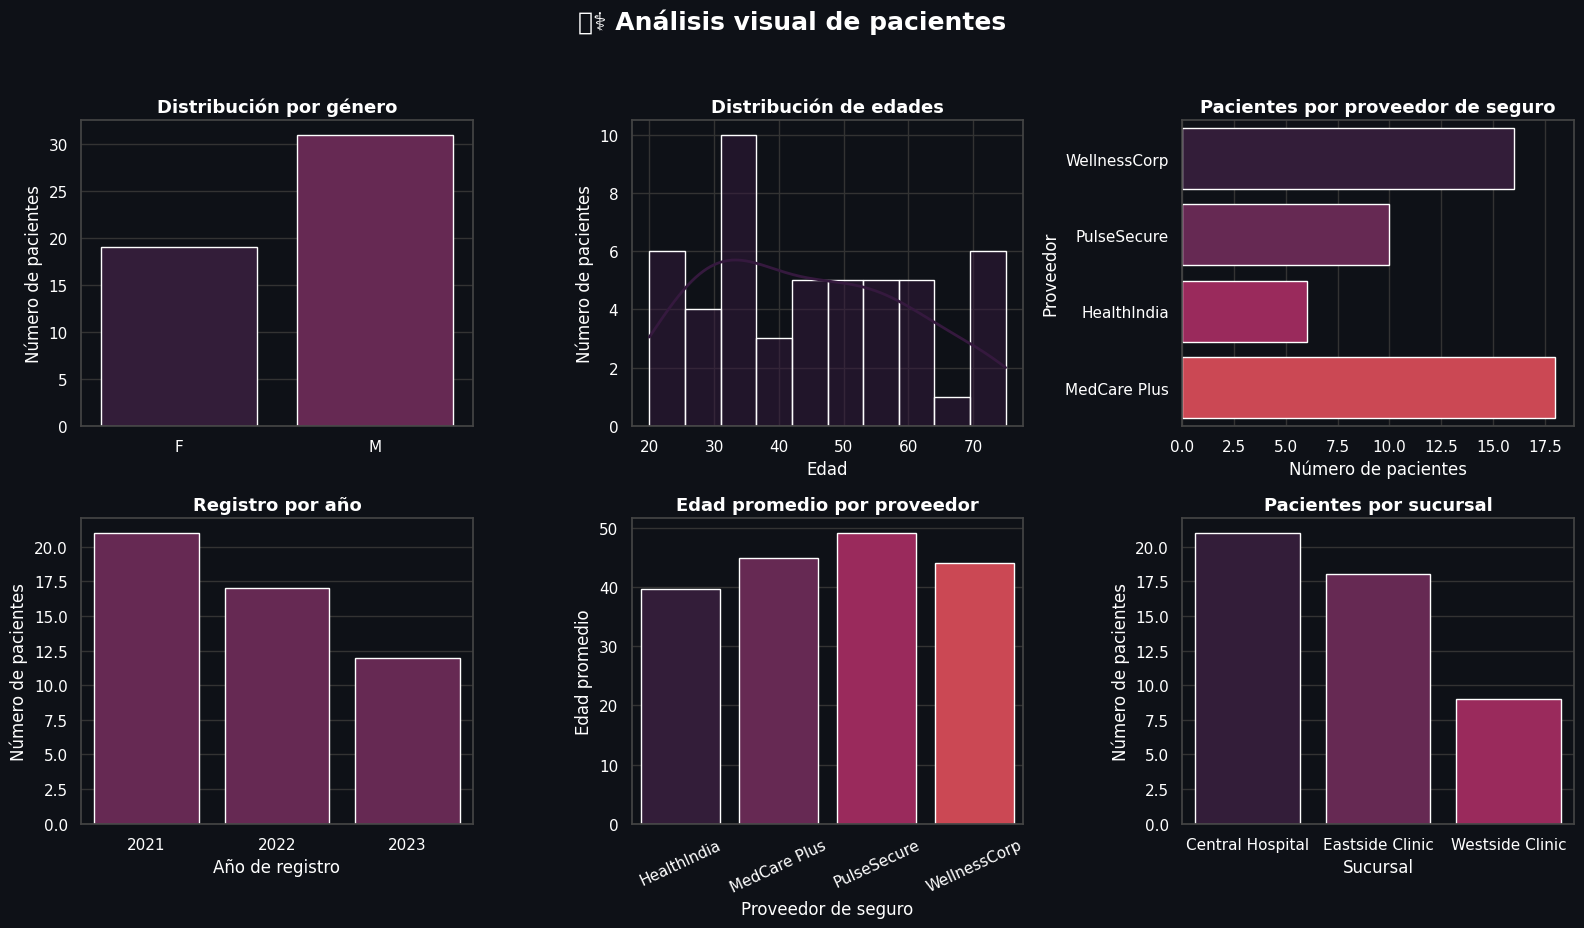

In [ ]:
# Preprocesamiento
df_pac['full_name'] = df_pac['first_name'] + ' ' + df_pac['last_name']
df_pac['date_of_birth'] = pd.to_datetime(df_pac['date_of_birth'])
df_pac['registration_date'] = pd.to_datetime(df_pac['registration_date'])
today = pd.Timestamp('today')
df_pac['age'] = (today - df_pac['date_of_birth']).dt.days // 365
df_pac['registration_year'] = df_pac['registration_date'].dt.year

# Paleta global
palette = sns.color_palette('rocket')

# Estilo oscuro
plt.style.use('dark_background')
sns.set(style='darkgrid', palette=palette)

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

# Crear figura
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('🧑‍⚕️ Análisis visual de pacientes', fontsize=18, weight='bold', color='white', y=1.03)

# 1. Distribución por género
sns.countplot(x='gender', data=df_pac, ax=axes[0,0], palette=palette[:2])
axes[0,0].set_title('Distribución por género')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Número de pacientes')

# 2. Distribución de edades con KDE resaltada
sns.histplot(df_pac['age'], bins=10, kde=True, color=palette[0],
             line_kws={'color': palette[2], 'linewidth': 2}, ax=axes[0,1])
axes[0,1].set_title('Distribución de edades')
axes[0,1].set_xlabel('Edad')
axes[0,1].set_ylabel('Número de pacientes')

# 3. Pacientes por proveedor de seguro
sns.countplot(y='insurance_provider', data=df_pac, ax=axes[0,2], palette=palette)
axes[0,2].set_title('Pacientes por proveedor de seguro')
axes[0,2].set_xlabel('Número de pacientes')
axes[0,2].set_ylabel('Proveedor')
axes[0,2].tick_params(axis='y', rotation=0)

# 4. Registro por año
sns.countplot(x='registration_year', data=df_pac, ax=axes[1,0], color=palette[1])
axes[1,0].set_title('Registro por año')
axes[1,0].set_xlabel('Año de registro')
axes[1,0].set_ylabel('Número de pacientes')

# 5. Edad promedio por proveedor de seguro
age_mean = df_pac.groupby('insurance_provider')['age'].mean().reset_index()
sns.barplot(x='insurance_provider', y='age', data=age_mean, ax=axes[1,1], palette=palette)
axes[1,1].set_title('Edad promedio por proveedor')
axes[1,1].set_xlabel('Proveedor de seguro')
axes[1,1].set_ylabel('Edad promedio')
axes[1,1].tick_params(axis='x', rotation=25)

# 6. Distribución por sucursal (pacientes únicos)
df_merge = df_appo.merge(df_doc[['doctor_id','hospital_branch']], on='doctor_id', how='left')
df_merge_unique = df_merge.drop_duplicates(subset='patient_id')
sns.countplot(x='hospital_branch', data=df_merge_unique, ax=axes[1,2], palette=palette)
axes[1,2].set_title('Pacientes por sucursal')
axes[1,2].set_xlabel('Sucursal')
axes[1,2].set_ylabel('Número de pacientes')

# Ajustes finales
plt.tight_layout()
plt.show()


##Conexión

In [ ]:
conn = sqlite3.connect(':memory:')
c = conn.cursor()
print("Successfully connected to SQLite database.")

Successfully connected to SQLite database.


##Creación de Tablas en SQL

In [ ]:
df_appo.to_sql('APPOINTMENTS', conn, if_exists='append', index = False)
df_billi.to_sql('BILLING', conn, if_exists='replace', index = False)
df_doc.to_sql('DOCTORS', conn, if_exists='replace', index = False)
df_pac.to_sql('PACIENTS', conn, if_exists='replace', index= False)
df_trat.to_sql('TREATMENT', conn, if_exists='replace', index = False)

200

In [ ]:
ls -la

total 16
drwxr-xr-x 1 root root 4096 Oct 23 13:40 ./
drwxr-xr-x 1 root root 4096 Oct 26 21:52 ../
drwxr-xr-x 4 root root 4096 Oct 23 13:40 .config/
drwxr-xr-x 1 root root 4096 Oct 23 13:40 sample_data/


##Reporte de resultados

In [ ]:
#Pacientes y Citas
query1 = """
SELECT
    p.first_name,
    p.last_name,
    a.appointment_date,
    a.reason_for_visit,
    a.status
FROM PACIENTS AS p
JOIN APPOINTMENTS AS a ON p.patient_id = a.patient_id;
"""

df_reporte1 = pd.read_sql_query(query1, conn)


In [ ]:
estilo_tablas(df_reporte1.head())

,first_name,last_name,appointment_date,reason_for_visit,status
0,David,Williams,2023-01-16 00:00:00,Emergency,Cancelled
1,David,Williams,2023-01-26 00:00:00,Follow-up,Scheduled
2,David,Williams,2023-04-01 00:00:00,Emergency,No-show
3,David,Williams,2023-04-09 00:00:00,Consultation,Scheduled
4,Emily,Smith,2023-01-20 00:00:00,Follow-up,Scheduled


/tmp/ipython-input-2886045183.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


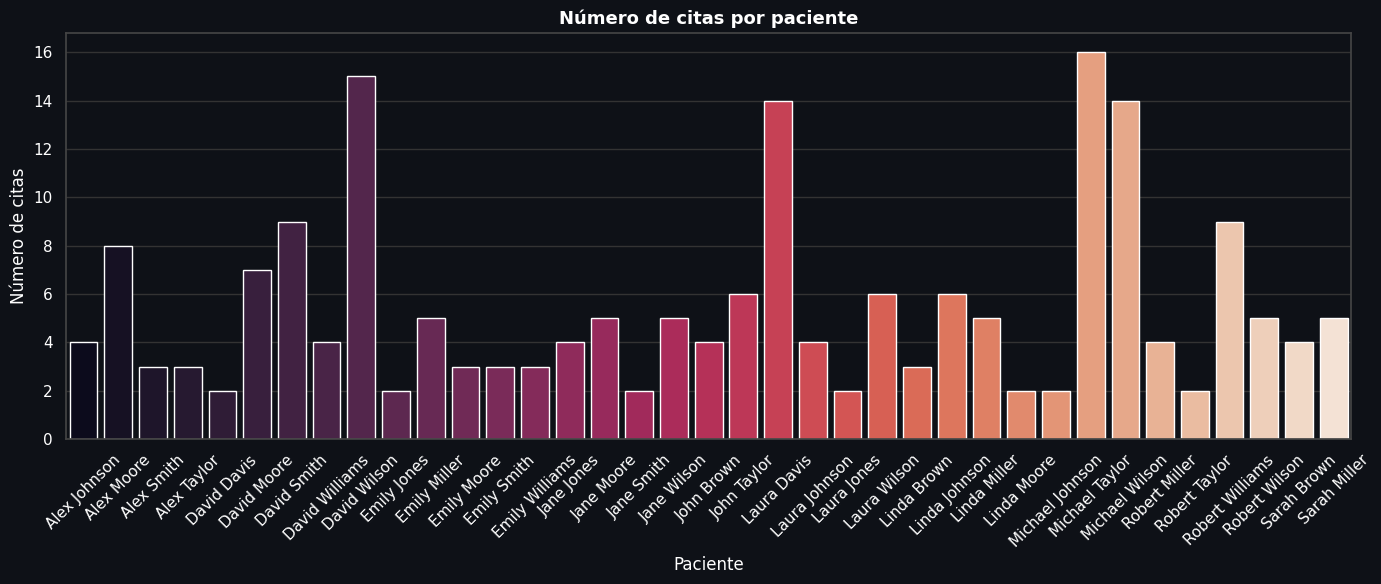

In [ ]:
# Contar número de citas por paciente
df_citas_por_paciente = df_reporte1.groupby(['first_name', 'last_name']).size().reset_index(name='num_citas')

# Crear columna con nombre completo
df_citas_por_paciente['full_name'] = df_citas_por_paciente['first_name'] + ' ' + df_citas_por_paciente['last_name']

# Estilo oscuro y paleta consistente
plt.style.use('dark_background')
sns.set(style='darkgrid', palette='rocket')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

# Gráfico
plt.figure(figsize=(14,6))
sns.barplot(
    data=df_citas_por_paciente,
    x='full_name',
    y='num_citas',
    palette='rocket'
)
plt.title('Número de citas por paciente')
plt.xlabel('Paciente')
plt.ylabel('Número de citas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-397052429.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-397052429.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


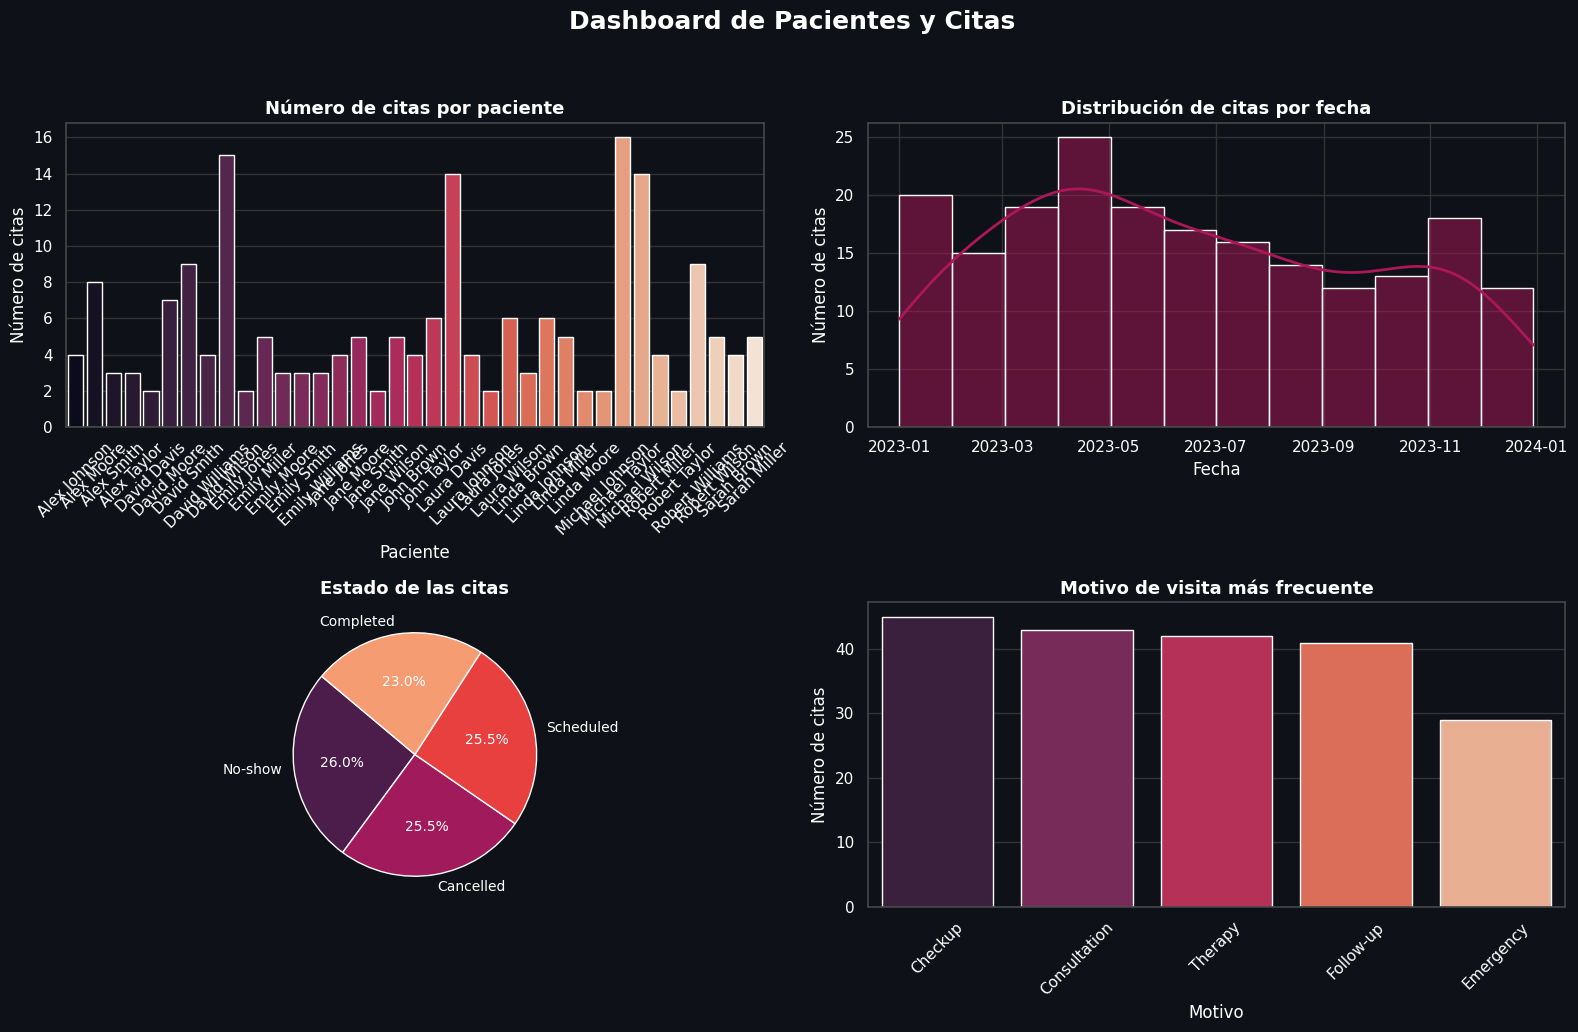

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Configuración de modo oscuro y paleta uniforme ---
plt.style.use('dark_background')
sns.set(style='darkgrid', palette='rocket')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

# --- Crear figura y subplots ---
fig, axes = plt.subplots(2, 2, figsize=(16,10))
fig.suptitle('Dashboard de Pacientes y Citas', fontsize=18, weight='bold', color='white', y=1.03)

# -------------------------------
# 1) Número de citas por paciente
df_citas_por_paciente = df_reporte1.groupby(['first_name', 'last_name']).size().reset_index(name='num_citas')
df_citas_por_paciente['full_name'] = df_citas_por_paciente['first_name'] + ' ' + df_citas_por_paciente['last_name']

sns.barplot(
    data=df_citas_por_paciente,
    x='full_name',
    y='num_citas',
    ax=axes[0,0],
    palette='rocket'
)
axes[0,0].set_title('Número de citas por paciente')
axes[0,0].set_xlabel('Paciente')
axes[0,0].set_ylabel('Número de citas')
axes[0,0].tick_params(axis='x', rotation=45)

# -------------------------------
# 2) Distribución de citas por fecha
df_reporte1['appointment_date'] = pd.to_datetime(df_reporte1['appointment_date'])
sns.histplot(
    df_reporte1['appointment_date'],
    bins=12,
    kde=True,
    color=sns.color_palette('rocket')[2],
    line_kws={'color': sns.color_palette('rocket')[4], 'linewidth': 2},
    ax=axes[0,1]
)
axes[0,1].set_title('Distribución de citas por fecha')
axes[0,1].set_xlabel('Fecha')
axes[0,1].set_ylabel('Número de citas')

# -------------------------------
# 3) Estado de las citas
estado_counts = df_reporte1['status'].value_counts()
axes[1,0].pie(
    estado_counts,
    labels=estado_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('rocket', len(estado_counts)),
    textprops={'color':'white', 'fontsize':10}
)
axes[1,0].set_title('Estado de las citas')

# -------------------------------
# 4) Motivo de visita más frecuente
motivo_counts = df_reporte1['reason_for_visit'].value_counts().reset_index()
motivo_counts.columns = ['reason', 'count']
sns.barplot(
    data=motivo_counts,
    x='reason',
    y='count',
    ax=axes[1,1],
    palette='rocket'
)
axes[1,1].set_title('Motivo de visita más frecuente')
axes[1,1].set_xlabel('Motivo')
axes[1,1].set_ylabel('Número de citas')
axes[1,1].tick_params(axis='x', rotation=45)

# --- Ajuste de layout y mostrar ---
plt.tight_layout()
plt.show()


###Doctores con mayor ingreso por cita

In [ ]:
c.execute('''
SELECT
    d.doctor_id,
    d.first_name || ' ' || d.last_name as doctor_nombre,
    d.specialization,
    COUNT(*) as citas_completadas,
    ROUND(AVG(t.cost), 2) as ingreso_promedio
FROM APPOINTMENTS a
LEFT JOIN DOCTORS d ON a.doctor_id = d.doctor_id
LEFT JOIN TREATMENT t ON a.appointment_id = t.appointment_id
WHERE a.status = 'Completed'
GROUP BY d.doctor_id, doctor_nombre, d.specialization
ORDER BY citas_completadas DESC
LIMIT 5;
          ''')
cons_1= DataFrame(c.fetchall(), columns=['doctor_id','doctor_nombre','specialization','citas_completadas','ingreso_promedio'])

In [ ]:
estilo_tablas(cons_1)

,doctor_id,doctor_nombre,specialization,citas_completadas,ingreso_promedio
0,D001,David Taylor,Dermatology,6,3039.030000
1,D003,Jane Smith,Pediatrics,6,1973.070000
2,D002,Jane Davis,Pediatrics,5,2928.300000
3,D006,Alex Davis,Pediatrics,5,3437.960000
4,D007,Robert Davis,Oncology,5,3495.880000


/tmp/ipython-input-2522239453.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


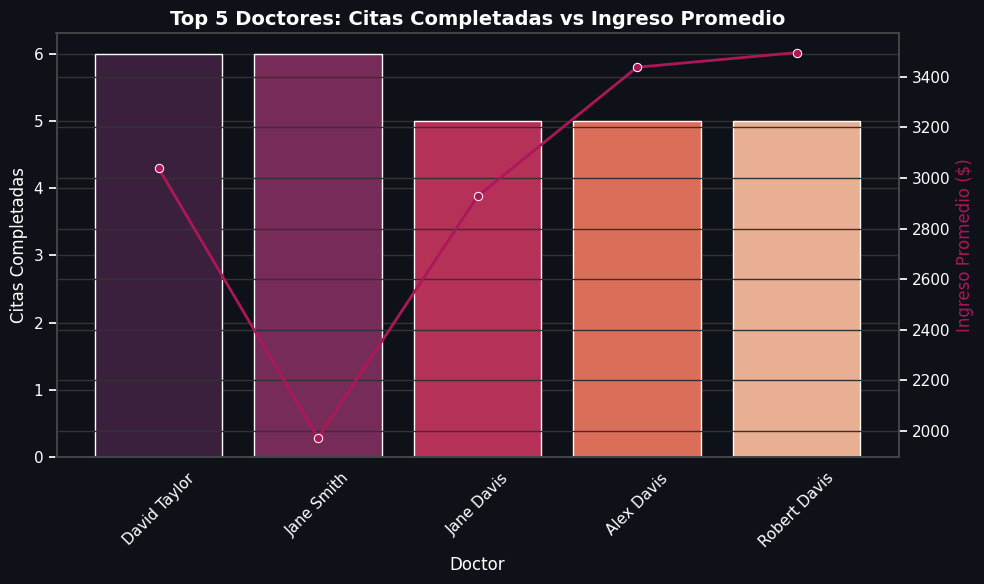

In [ ]:
# Estilo oscuro y paleta uniforme
plt.style.use('dark_background')
sns.set(style='darkgrid', palette='rocket')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

#Crear figur
fig, ax1 = plt.subplots(figsize=(10,6))

# Gráfico de barras: Citas completadas
sns.barplot(
    x='doctor_nombre',
    y='citas_completadas',
    data=cons_1,
    palette=sns.color_palette('rocket', len(cons_1)),
    ax=ax1
)
ax1.set_ylabel('Citas Completadas', color='white', fontsize=12)
ax1.set_xlabel('Doctor', color='white', fontsize=12)
ax1.set_title('Top 5 Doctores: Citas Completadas vs Ingreso Promedio', fontsize=14, color='white')
ax1.tick_params(axis='x', rotation=45)

# Segundo eje Y: Ingreso promedio
ax2 = ax1.twinx()
sns.lineplot(
    x='doctor_nombre',
    y='ingreso_promedio',
    data=cons_1,
    sort=False,
    color=sns.color_palette('rocket')[2],  # línea de la paleta rocket
    marker='o',
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('Ingreso Promedio ($)', color=sns.color_palette('rocket')[2], fontsize=12)

plt.tight_layout()
plt.show()

###Información acerca de los montos por tipo de pago

In [ ]:
c.execute('''
SELECT
    payment_method,
    COUNT(*) as total_transacciones,
    SUM(amount) as monto_total,
    ROUND(AVG(amount), 2) as promedio_transaccion
FROM BILLING
GROUP BY payment_method
ORDER BY monto_total DESC;
''')
cons_3=DataFrame(c.fetchall(), columns=['payment_method','total_transacciones','monto_total','promedio_transaccion'])

In [ ]:
estilo_tablas(cons_3)

,payment_method,total_transacciones,monto_total,promedio_transaccion
0,Credit Card,75,201382.430000,2685.100000
1,Insurance,64,182160.280000,2846.250000
2,Cash,61,167707.140000,2749.300000


/tmp/ipython-input-1926892234.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


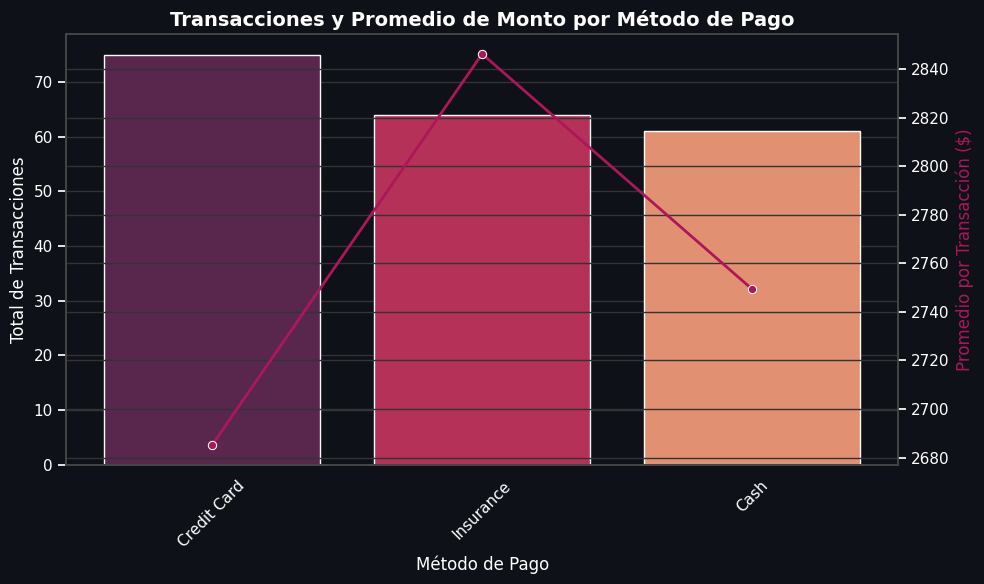

In [ ]:
#Estilo oscuro y paleta uniforme
sns.set(style='darkgrid', palette='rocket')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

#Crear figura
fig, ax1 = plt.subplots(figsize=(10,6))

# Gráfico de barras: total de transacciones por método de pago
sns.barplot(
    x='payment_method',
    y='total_transacciones',
    data=cons_3,
    palette=sns.color_palette('rocket', len(cons_3)),
    ax=ax1
)
ax1.set_xlabel('Método de Pago', color='white', fontsize=12)
ax1.set_ylabel('Total de Transacciones', color='white', fontsize=12)
ax1.set_title('Transacciones y Promedio de Monto por Método de Pago', color='white', fontsize=14)
ax1.tick_params(axis='x', rotation=45)

# Segundo eje Y: monto promedio
ax2 = ax1.twinx()
sns.lineplot(
    x='payment_method',
    y='promedio_transaccion',
    data=cons_3,
    color=sns.color_palette('rocket')[2],  # línea con color de la misma paleta
    marker='o',
    linewidth=2,
    sort=False,
    ax=ax2)

ax2.set_ylabel('Promedio por Transacción ($)', color=sns.color_palette('rocket')[2], fontsize=12)

plt.tight_layout()
plt.show()


###Doctores con más experiencia a partir de 20 años

In [ ]:
c.execute('''
SELECT
    doctor_id,
    first_name,
    last_name,
    specialization,
    years_experience
FROM DOCTORS
WHERE years_experience > 20
ORDER BY years_experience DESC;

''')
cons_4=DataFrame(c.fetchall(),columns=['doctor_id','first_name','last_name','specialization','years_experience'])

In [ ]:
estilo_tablas(cons_4)

,doctor_id,first_name,last_name,specialization,years_experience
0,D004,David,Jones,Pediatrics,28
1,D005,Sarah,Taylor,Dermatology,26
2,D007,Robert,Davis,Oncology,26
3,D009,Sarah,Smith,Pediatrics,26
4,D002,Jane,Davis,Pediatrics,24
5,D006,Alex,Davis,Pediatrics,23
6,D010,Linda,Wilson,Oncology,21


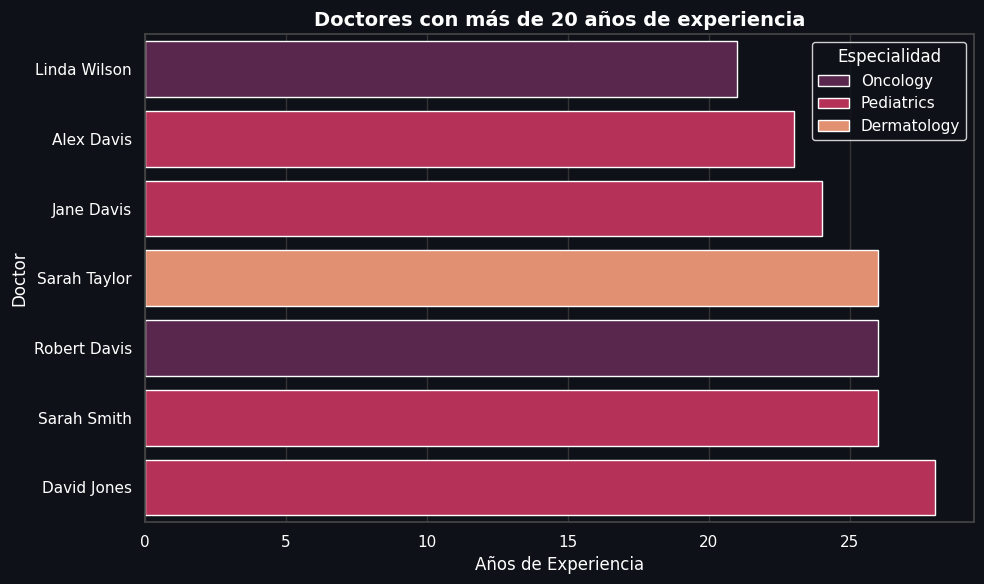

In [ ]:
#Estilo oscuro y paleta uniforme
plt.style.use('dark_background')
sns.set(style='darkgrid', palette='rocket')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

#Crear columna con nombre completo
cons_4['doctor_nombre'] = cons_4['first_name'] + ' ' + cons_4['last_name']

# Filtrar doctores con más de 20 años de experiencia
cons_4_filtrado = cons_4[cons_4['years_experience'] > 20].sort_values('years_experience', ascending=True)

#Crear figura
plt.figure(figsize=(10,6))
sns.barplot(
    x='years_experience',
    y='doctor_nombre',
    hue='specialization',
    data=cons_4_filtrado,
    dodge=False,
    palette=sns.color_palette('rocket', cons_4_filtrado['specialization'].nunique())
)

plt.xlabel('Años de Experiencia', color='white', fontsize=12)
plt.ylabel('Doctor', color='white', fontsize=12)
plt.title('Doctores con más de 20 años de experiencia', color='white', fontsize=14)
plt.legend(title='Especialidad', facecolor='#0e1117', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()


###Análisis de los métodos de pago

In [ ]:
c.execute('''
CREATE TABLE treatment_billing_report AS
SELECT
    b.bill_id,
    b.patient_id,
    b.treatment_id,
    b.bill_date,
    b.amount,
    b.payment_method,
    b.payment_status,
    t.treatment_type as treatment_type
FROM BILLING b
LEFT JOIN TREATMENT t ON b.treatment_id = t.treatment_id
''')

df_treatment_billing_report = pd.read_sql_query('SELECT * FROM treatment_billing_report', conn)




In [ ]:
estilo_tablas(df_treatment_billing_report.head())

,bill_id,patient_id,treatment_id,bill_date,amount,payment_method,payment_status,treatment_type
0,B001,P034,T001,2023-08-09 00:00:00,3941.970000,Insurance,Pending,Chemotherapy
1,B002,P032,T002,2023-06-09 00:00:00,4158.440000,Insurance,Paid,MRI
2,B003,P048,T003,2023-06-28 00:00:00,3731.550000,Insurance,Paid,MRI
3,B004,P025,T004,2023-09-01 00:00:00,4799.860000,Insurance,Failed,MRI
4,B005,P040,T005,2023-07-06 00:00:00,582.050000,Credit Card,Pending,ECG


/tmp/ipython-input-1607038103.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


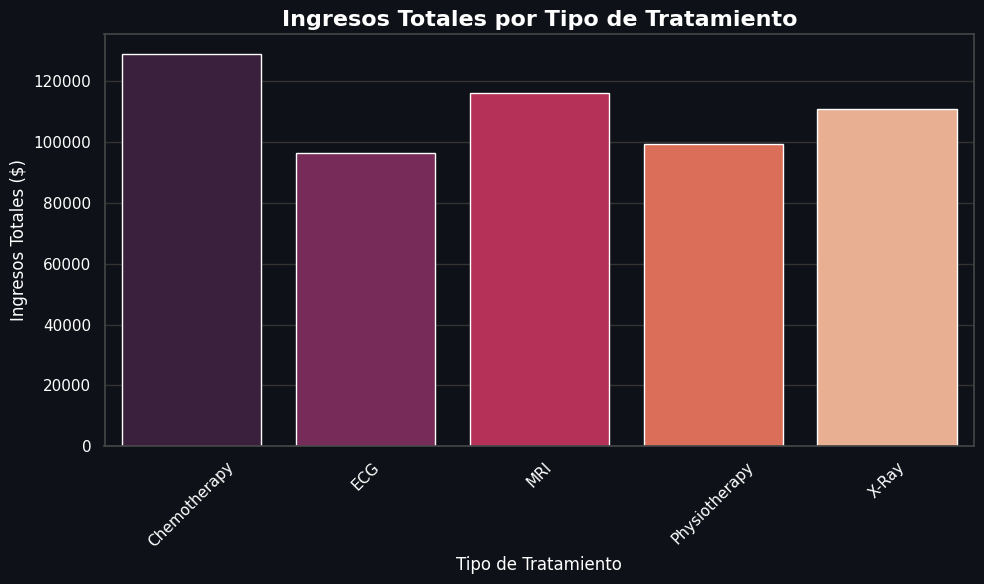

In [ ]:
#Estilo oscuro y paleta uniforme
plt.style.use('dark_background')
sns.set(style='darkgrid', palette='rocket')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

#Agrupar ingresos por tipo de tratamiento
ingresos_tratamiento = df_treatment_billing_report.groupby('treatment_type')['amount'].sum().reset_index()

#Crear gráfico de barras
plt.figure(figsize=(10,6))
sns.barplot(
    data=ingresos_tratamiento,
    x='treatment_type',
    y='amount',
    palette=sns.color_palette('rocket', len(ingresos_tratamiento))
)
plt.title('Ingresos Totales por Tipo de Tratamiento', color='white', fontsize=16)
plt.xlabel('Tipo de Tratamiento', color='white')
plt.ylabel('Ingresos Totales ($)', color='white')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Número de tratamientos cuyo método de pago fue el seguro clasificados por el tipo de tratamiento y el estado de pago

In [ ]:
c.execute('''
SELECT
    treatment_type,
    payment_status,
    COUNT(*) as number_of_bills
FROM treatment_billing_report
WHERE payment_method = 'Insurance'
GROUP BY treatment_type, payment_status
ORDER BY treatment_type, payment_status
''')
insurance_payments = c.fetchall()
insurance_payments = pd.DataFrame(insurance_payments, columns=['treatment_type', 'payment_status', 'number_of_bills'])

insurance_payments = insurance_payments.pivot_table(
    index='treatment_type',
    columns='payment_status',
    values='number_of_bills',
    fill_value=0
)




In [ ]:
estilo_tablas(insurance_payments)

payment_status,Failed,Paid,Pending
treatment_type,,,
Chemotherapy,3.000000,2.000000,6.000000
ECG,3.000000,1.000000,4.000000
MRI,6.000000,7.000000,4.000000
Physiotherapy,5.000000,3.000000,3.000000
X-Ray,4.000000,7.000000,6.000000


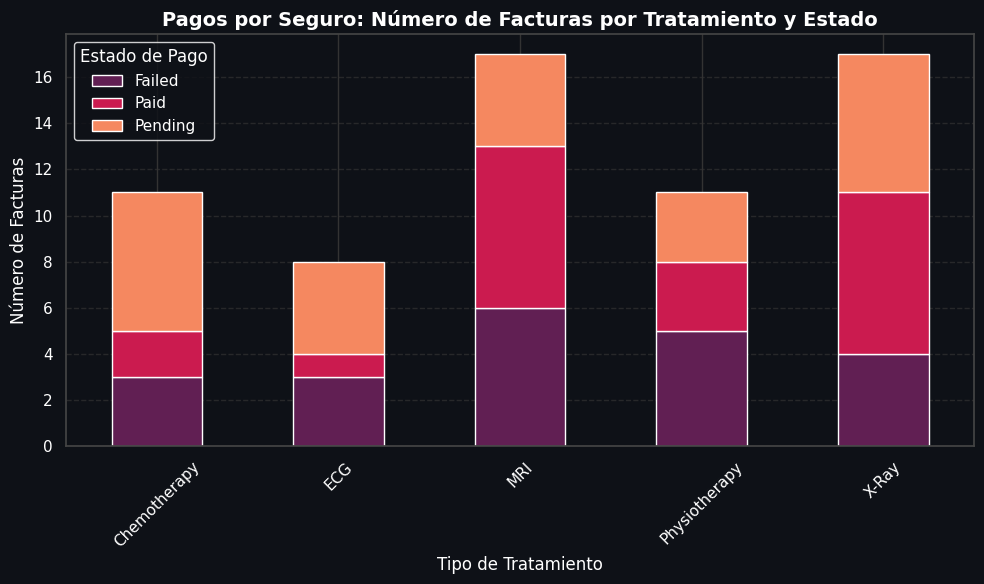

In [ ]:
#Estilo oscuro y paleta uniforme
plt.style.use('dark_background')
sns.set(style='darkgrid', palette='rocket')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

#Gráfico de barras apiladas
ax = insurance_payments.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=sns.color_palette('rocket', len(insurance_payments.columns))
)

ax.set_title('Pagos por Seguro: Número de Facturas por Tratamiento y Estado', fontsize=14, color='white')
ax.set_xlabel('Tipo de Tratamiento', color='white')
ax.set_ylabel('Número de Facturas', color='white')
ax.tick_params(axis='x', rotation=45, colors='white')
ax.tick_params(axis='y', colors='white')
ax.legend(title='Estado de Pago', facecolor='#0e1117', edgecolor='white', labelcolor='white')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Distribución de los métodos de pago para facturas menores a $2,000

In [ ]:
c.execute('''
SELECT
    payment_method,
    COUNT(*) as number_of_bills
FROM treatment_billing_report
WHERE amount < 2000
GROUP BY payment_method
''')
bills_over_2000 = c.fetchall()
bills_over_2000 = pd.DataFrame(bills_over_2000, columns=['payment_method', 'number_of_bills'])


In [ ]:
estilo_tablas(bills_over_2000)

,payment_method,number_of_bills
0,Cash,19
1,Credit Card,27
2,Insurance,22


/tmp/ipython-input-3654934283.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


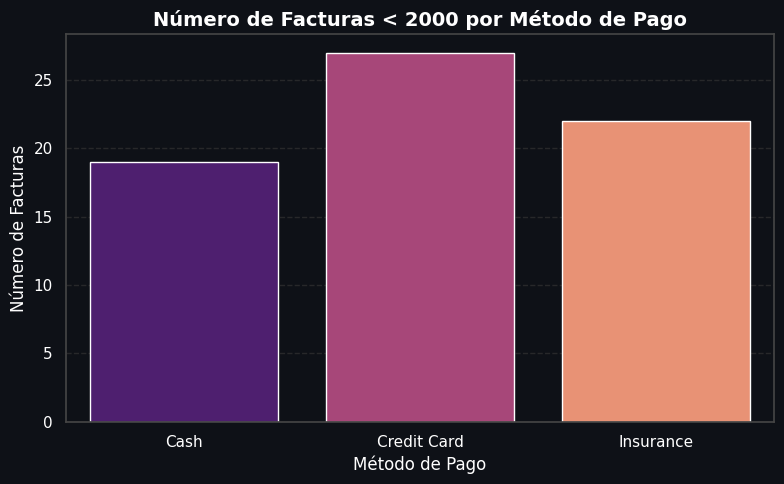

In [ ]:
#Estilo oscuro y paleta uniforme
plt.style.use('dark_background')
sns.set(style='darkgrid', palette='rocket')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

# Crear figura
plt.figure(figsize=(8,5))

# Gráfico de barras: facturas menores a 2000 por método de pago
sns.barplot(
    data=bills_over_2000,
    x='payment_method',
    y='number_of_bills',
    palette='magma'
)

# Títulos y etiquetas
plt.title('Número de Facturas < 2000 por Método de Pago', fontsize=14, color='white')
plt.xlabel('Método de Pago', color='white')
plt.ylabel('Número de Facturas', color='white')

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ajuste final
plt.tight_layout()
plt.show()



###Total de Ingresos clasificados por el tipo de tratamiento

In [ ]:
c.execute('''
SELECT
    treatment_type,
    SUM(amount) as total_revenue
FROM treatment_billing_report
GROUP BY treatment_type
ORDER BY total_revenue DESC
''')
revenue_by_treatment = c.fetchall()
revenue_by_treatment = pd.DataFrame(revenue_by_treatment, columns=['treatment_type', 'total_revenue'])


In [ ]:
estilo_tablas(revenue_by_treatment)

,treatment_type,total_revenue
0,Chemotherapy,128855.680000
1,MRI,116098.160000
2,X-Ray,110653.670000
3,Physiotherapy,99418.100000
4,ECG,96224.240000


/tmp/ipython-input-3690649787.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


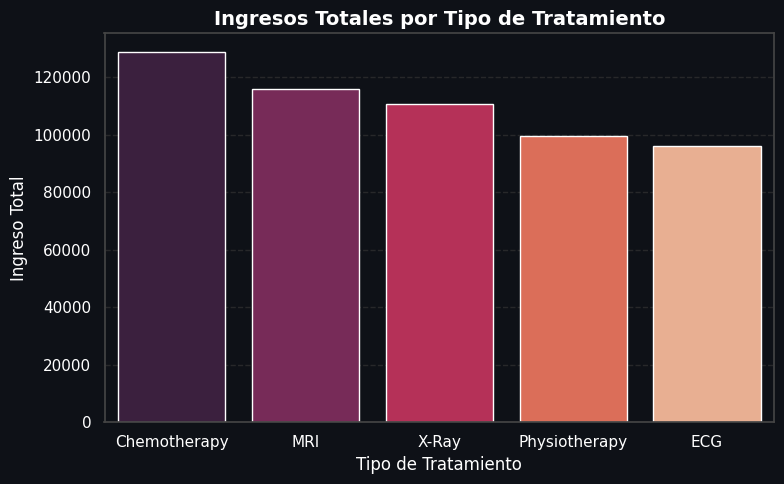

In [ ]:
# --- Estilo oscuro y paleta uniforme ---
plt.style.use('dark_background')
sns.set(style='darkgrid', palette='rocket')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

# --- Gráfico de barras ---
plt.figure(figsize=(8,5))
sns.barplot(
    data=revenue_by_treatment,
    x='treatment_type',
    y='total_revenue',
    palette=sns.color_palette('rocket', len(revenue_by_treatment['treatment_type']))
)

plt.title('Ingresos Totales por Tipo de Tratamiento', fontsize=14, color='white')
plt.xlabel('Tipo de Tratamiento', color='white')
plt.ylabel('Ingreso Total', color='white')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



### Número de citas por doctor dado que los pacientes fueron a Consulta

In [ ]:
c.execute('''
SELECT
    d.first_name,
    d.last_name,
    a.reason_for_visit,
    COUNT(*) as number_of_appointments
FROM APPOINTMENTS a
JOIN DOCTORS d ON a.doctor_id = d.doctor_id
WHERE a.reason_for_visit LIKE '%Consultation%'
GROUP BY d.first_name, d.last_name, a.reason_for_visit
ORDER BY d.first_name, d.last_name, a.reason_for_visit
''')
consultation_appointments = c.fetchall()
consultation_appointments = pd.DataFrame(consultation_appointments, columns=['doctor_first_name', 'doctor_last_name', 'reason_for_visit', 'number_of_appointments'])


In [ ]:
estilo_tablas(consultation_appointments)

,doctor_first_name,doctor_last_name,reason_for_visit,number_of_appointments
0,Alex,Davis,Consultation,3
1,David,Jones,Consultation,5
2,David,Taylor,Consultation,4
3,Jane,Davis,Consultation,3
4,Jane,Smith,Consultation,8
5,Linda,Brown,Consultation,5
6,Linda,Wilson,Consultation,3
7,Robert,Davis,Consultation,2
8,Sarah,Smith,Consultation,4
9,Sarah,Taylor,Consultation,6


/tmp/ipython-input-1130999864.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


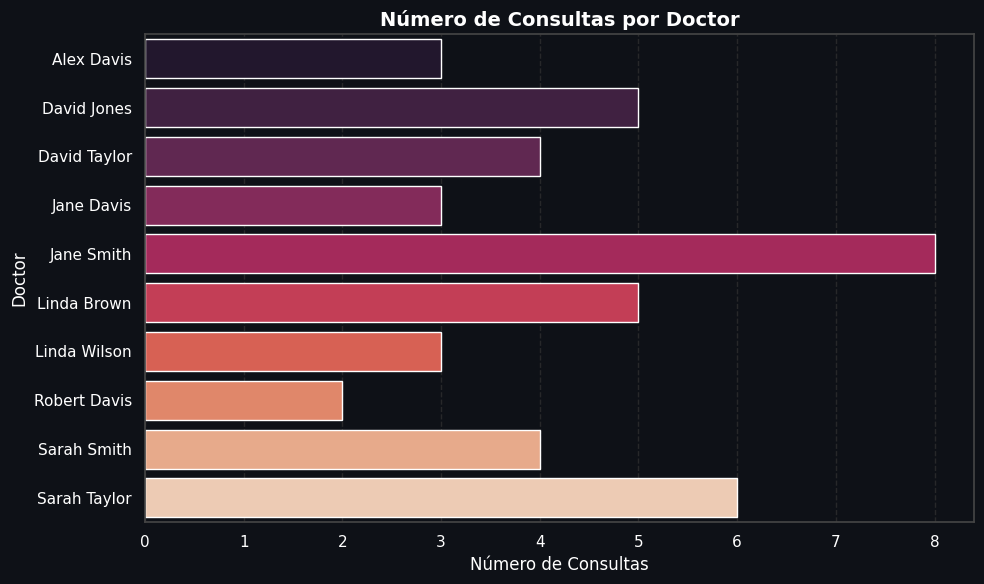

In [ ]:
# Estilo oscuro
plt.style.use('dark_background')
sns.set(style='darkgrid')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

# Crear columna con nombre completo del doctor
consultation_appointments['doctor_full_name'] = consultation_appointments['doctor_first_name'] + ' ' + consultation_appointments['doctor_last_name']

# Gráfico de barras horizontal
plt.figure(figsize=(10,6))
sns.barplot(
    data=consultation_appointments,
    y='doctor_full_name',
    x='number_of_appointments',
    palette=sns.color_palette('rocket', len(consultation_appointments))
)

plt.title('Número de Consultas por Doctor', fontsize=14, color='white')
plt.xlabel('Número de Consultas', color='white')
plt.ylabel('Doctor', color='white')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


###Total de pagos por estado

In [ ]:
c.execute('''
SELECT
payment_status,
COUNT(*) AS pacientes
FROM BILLING
GROUP BY payment_status;
''')
cons_11=DataFrame(c.fetchall(), columns=("payment_status","pacientes"))


In [ ]:
estilo_tablas(cons_11)

,payment_status,pacientes
0,Failed,67
1,Paid,64
2,Pending,69


/tmp/ipython-input-1754966454.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


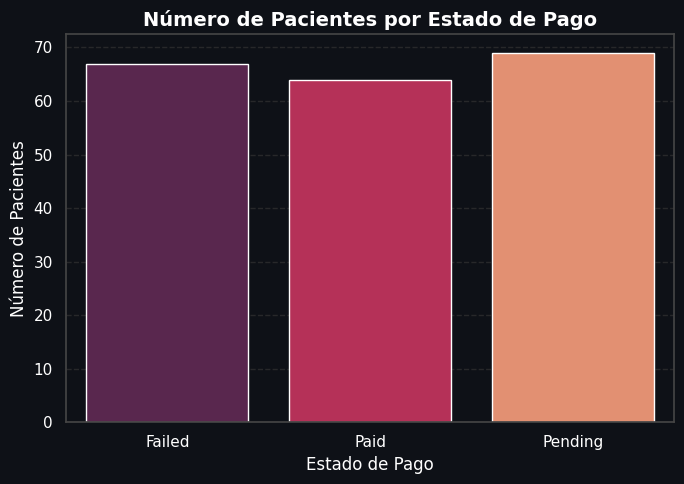

In [ ]:
# Estilo oscuro
plt.style.use('dark_background')
sns.set(style='darkgrid')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

# Gráfico de barras vertical
plt.figure(figsize=(7,5))
sns.barplot(
    data=cons_11,
    x='payment_status',
    y='pacientes',
    palette=sns.color_palette('rocket', len(cons_11['payment_status']))
)

plt.title('Número de Pacientes por Estado de Pago', fontsize=14, color='white')
plt.xlabel('Estado de Pago', color='white')
plt.ylabel('Número de Pacientes', color='white')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


###Ingreso Maximo por tipo de pago si ya ha sido pagado

In [ ]:
c.execute('''
    SELECT
    payment_method,
    MAX(amount) AS monto_maximo
    FROM BILLING
    WHERE payment_status = "Paid"
    GROUP BY payment_method;
''')
cons_10=DataFrame(c.fetchall(),columns=("payment_method","monto_maximo"))


In [ ]:
estilo_tablas(cons_10)

,payment_method,monto_maximo
0,Cash,4973.630000
1,Credit Card,4834.020000
2,Insurance,4846.200000


/tmp/ipython-input-1829227333.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


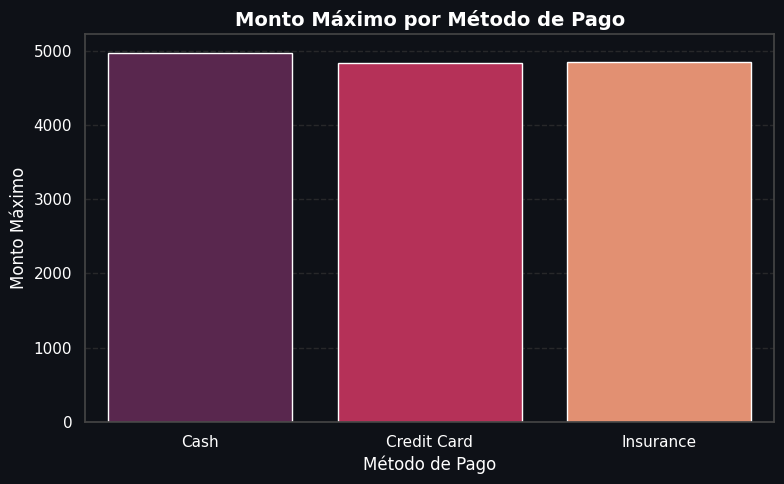

In [ ]:
# Estilo oscuro
plt.style.use('dark_background')
sns.set(style='darkgrid')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

# Gráfico de barras vertical
plt.figure(figsize=(8,5))
sns.barplot(
    data=cons_10,
    x='payment_method',
    y='monto_maximo',
    palette=sns.color_palette('rocket', len(cons_10['payment_method']))
)

plt.title('Monto Máximo por Método de Pago', fontsize=14, color='white')
plt.xlabel('Método de Pago', color='white')
plt.ylabel('Monto Máximo', color='white')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



### Porcentaje de pacientes en cada aseguradora

In [ ]:
c.execute('''
SELECT
    insurance_provider as aseguradora,
    COUNT(*) as total_pacientes,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM PACIENTS), 2) as porcentaje
FROM PACIENTS
WHERE insurance_provider IS NOT NULL
GROUP BY insurance_provider
ORDER BY total_pacientes DESC;
      ''')
cons_12=DataFrame(c.fetchall(),columns=("Aseguradora","pacientes_total","% total de asegurados"))


In [ ]:
estilo_tablas(cons_12)

,Aseguradora,pacientes_total,% total de asegurados
0,MedCare Plus,18,36.000000
1,WellnessCorp,16,32.000000
2,PulseSecure,10,20.000000
3,HealthIndia,6,12.000000


/tmp/ipython-input-989098409.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


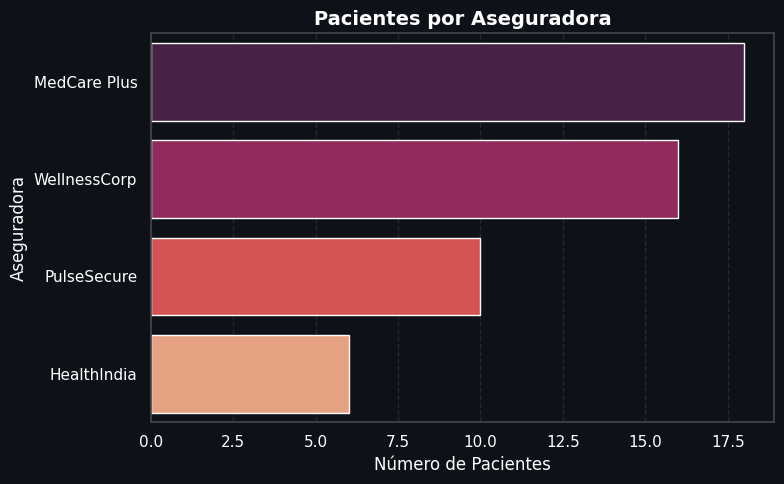

In [ ]:
#Estilo oscuro
plt.style.use('dark_background')
sns.set(style='darkgrid')

plt.rcParams.update({
    'axes.facecolor': '#0e1117',
    'figure.facecolor': '#0e1117',
    'axes.edgecolor': '#444444',
    'grid.color': '#333333',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})

#Gráfico de barras
plt.figure(figsize=(8,5))
sns.barplot(
    data=cons_12,
    y='Aseguradora',
    x='pacientes_total',
    palette=sns.color_palette('rocket', len(cons_12['Aseguradora']))
)

plt.title('Pacientes por Aseguradora', fontsize=14, color='white')
plt.xlabel('Número de Pacientes', color='white')
plt.ylabel('Aseguradora', color='white')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Conclusiones

En este proyecto se construyó una base de datos hospitalaria con 5 tablas: pacientes, citas ,doctores, tratamiento y facturación.
Se integraron mediante SQL en un entorno SQLite, creando un reporte con información relevante de cada paciente y sus servicios.
Las consultas permitieron identificar los pacientes con montos altos, facturas pequeñas, nombres específicos y métodos de pago frecuentes.
El uso de SQLite dentro de Colab facilitó la manipulación, unión y análisis de los datos en un entorno reproducible y eficiente.
Este ejercicio permitió comprender la utilidad práctica de SQL para generar reportes a partir de múltiples fuentes de información.

#**Parte 2.**
Se entrega como una celda de texto en el Colab donde desarrollaron los pasos en SQL Lite

Con el uso de SAS y como se reviso en clase, deberán regenerar sus pasos utilizando los procedimientos propios de SAS o bien usando un "PROC SQL", para la generación de reportes estan habilidados para realizarlos con el uso de comandos de SAS o SQL.

Nota: como en SAS Acadey se complica compartir archivos, deberán importar los datos desde el programa de SAS, es decir deberán pegar los datos en un procedimiento "DATA". Se solicita hacerlo de esta forma para que el profesor pueda validar sus resultados.

### Limpieza de algunas de las columnas de las tablas para que no afecten el código de la inserción de datos en SAS


In [ ]:
# Cambia los espacios de los registros de la columna por guiones bajos
# Tabla APPOINTMENTS
df_appo['reason_for_visit'] = df_appo['reason_for_visit'].str.replace(' ', '_')
df_appo['status'] = df_appo['status'].str.replace(' ', '_')

#Tabla BILLING
df_billi['payment_method'] = df_billi['payment_method'].str.replace(' ', '_')
df_billi['payment_status'] = df_billi['payment_status'].str.replace(' ', '_')

#Tabla TREATMENT
df_trat['treatment_type'] = df_trat['treatment_type'].str.replace(' ', '_')
df_trat['description'] = df_trat['description'].str.replace(' ', '_')

#Tabla DOCTORS
df_doc['specialization'] = df_doc['specialization'].str.replace(' ', '_')
df_doc['hospital_branch'] = df_doc['hospital_branch'].str.replace(' ', '_')

#Tabla PACIENTS
df_pac['insurance_provider'] = df_pac['insurance_provider'].str.replace(' ', '_')
df_pac['address'] = df_pac['address'].str.replace(' ', '_')

### Transformación de los datos de las 5 tablas en líneas de formato SAS

In [ ]:
#Tabla APPOINTMENTS
#Reccorre cada renglón del DataFrame y la devualve como una tupla
for row in df_appo.itertuples(index=False):
    # Imprime los elementos de cada tupla se convierten en una cadena de texto y los separa por medio de espacios
    print(" ".join(map(str,row)))

A001 P034 D009 2023-08-09 00:00:00 15 Therapy Scheduled 8
A002 P032 D004 2023-06-09 00:00:00 14 Therapy No-show 6
A003 P048 D004 2023-06-28 00:00:00 8 Consultation Cancelled 6
A004 P025 D006 2023-09-01 00:00:00 9 Consultation Cancelled 9
A005 P040 D003 2023-07-06 00:00:00 12 Emergency No-show 7
A006 P045 D006 2023-06-19 00:00:00 16 Checkup Scheduled 6
A007 P001 D007 2023-04-09 00:00:00 10 Consultation Scheduled 4
A008 P016 D010 2023-05-24 00:00:00 8 Consultation Cancelled 5
A009 P039 D010 2023-03-05 00:00:00 13 Follow-up Scheduled 3
A010 P005 D003 2023-01-13 00:00:00 15 Therapy Completed 1
A011 P022 D007 2023-11-12 00:00:00 16 Checkup No-show 11
A012 P029 D003 2023-05-07 00:00:00 10 Follow-up Completed 5
A013 P003 D002 2023-08-16 00:00:00 12 Emergency Scheduled 8
A014 P012 D010 2023-05-25 00:00:00 10 Emergency Cancelled 5
A015 P026 D004 2023-01-15 00:00:00 17 Consultation No-show 1
A016 P016 D008 2023-06-30 00:00:00 11 Consultation Scheduled 6
A017 P037 D009 2023-07-11 00:00:00 17 Emer

In [ ]:
# Tabla BILLING
for row in df_billi.itertuples(index=False):
    print(" ".join(map(str,row)))

B001 P034 T001 2023-08-09 00:00:00 3941.97 Insurance Pending 8 2023
B002 P032 T002 2023-06-09 00:00:00 4158.44 Insurance Paid 6 2023
B003 P048 T003 2023-06-28 00:00:00 3731.55 Insurance Paid 6 2023
B004 P025 T004 2023-09-01 00:00:00 4799.86 Insurance Failed 9 2023
B005 P040 T005 2023-07-06 00:00:00 582.05 Credit_Card Pending 7 2023
B006 P045 T006 2023-06-19 00:00:00 1381.0 Insurance Pending 6 2023
B007 P001 T007 2023-04-09 00:00:00 534.03 Cash Failed 4 2023
B008 P016 T008 2023-05-24 00:00:00 3413.64 Cash Failed 5 2023
B009 P039 T009 2023-03-05 00:00:00 4541.14 Credit_Card Paid 3 2023
B010 P005 T010 2023-01-13 00:00:00 1595.67 Cash Paid 1 2023
B011 P022 T011 2023-11-12 00:00:00 4671.66 Cash Failed 11 2023
B012 P029 T012 2023-05-07 00:00:00 771.2 Insurance Pending 5 2023
B013 P003 T013 2023-08-16 00:00:00 4704.96 Cash Paid 8 2023
B014 P012 T014 2023-05-25 00:00:00 2082.3 Credit_Card Paid 5 2023
B015 P026 T015 2023-01-15 00:00:00 956.39 Insurance Pending 1 2023
B016 P016 T016 2023-06-30 0

In [ ]:
# Tabla TREATMENT
for row in df_trat.itertuples(index=False):
    print(" ".join(map(str,row)))

T001 A001 Chemotherapy Basic_screening 3941.97 2023-08-09 00:00:00 8 2023
T002 A002 MRI Advanced_protocol 4158.44 2023-06-09 00:00:00 6 2023
T003 A003 MRI Standard_procedure 3731.55 2023-06-28 00:00:00 6 2023
T004 A004 MRI Basic_screening 4799.86 2023-09-01 00:00:00 9 2023
T005 A005 ECG Standard_procedure 582.05 2023-07-06 00:00:00 7 2023
T006 A006 Chemotherapy Standard_procedure 1381.0 2023-06-19 00:00:00 6 2023
T007 A007 Chemotherapy Advanced_protocol 534.03 2023-04-09 00:00:00 4 2023
T008 A008 Physiotherapy Basic_screening 3413.64 2023-05-24 00:00:00 5 2023
T009 A009 Physiotherapy Standard_procedure 4541.14 2023-03-05 00:00:00 3 2023
T010 A010 Physiotherapy Standard_procedure 1595.67 2023-01-13 00:00:00 1 2023
T011 A011 MRI Basic_screening 4671.66 2023-11-12 00:00:00 11 2023
T012 A012 Chemotherapy Standard_procedure 771.2 2023-05-07 00:00:00 5 2023
T013 A013 MRI Standard_procedure 4704.96 2023-08-16 00:00:00 8 2023
T014 A014 ECG Basic_screening 2082.3 2023-05-25 00:00:00 5 2023
T015

In [ ]:
# Tabla DOCTORS
for row in df_doc.itertuples(index=False):
    print(" ".join(map(str,row)))

D001 David Taylor Dermatology 8322010158 17 Westside_Clinic dr.david.taylor@hospital.com David Taylor
D002 Jane Davis Pediatrics 9004382050 24 Eastside_Clinic dr.jane.davis@hospital.com Jane Davis
D003 Jane Smith Pediatrics 8737740598 19 Eastside_Clinic dr.jane.smith@hospital.com Jane Smith
D004 David Jones Pediatrics 6594221991 28 Central_Hospital dr.david.jones@hospital.com David Jones
D005 Sarah Taylor Dermatology 9118538547 26 Central_Hospital dr.sarah.taylor@hospital.com Sarah Taylor
D006 Alex Davis Pediatrics 6570137231 23 Central_Hospital dr.alex.davis@hospital.com Alex Davis
D007 Robert Davis Oncology 8217493115 26 Westside_Clinic dr.robert.davis@hospital.com Robert Davis
D008 Linda Brown Dermatology 9069162601 5 Westside_Clinic dr.linda.brown@hospital.com Linda Brown
D009 Sarah Smith Pediatrics 7387087517 26 Central_Hospital dr.sarah.smith@hospital.com Sarah Smith
D010 Linda Wilson Oncology 6176383634 21 Eastside_Clinic dr.linda.wilson@hospital.com Linda Wilson


In [ ]:
# Tabla PACIENTS
for row in df_pac.itertuples(index=False):
    print(" ".join(map(str,row)))

P001 David Williams F 1955-06-04 00:00:00 6939585183 789_Pine_Rd 2022-06-23 00:00:00 WellnessCorp INS840674 david.williams@mail.com David Williams 70 2022
P002 Emily Smith F 1984-10-12 00:00:00 8228188767 321_Maple_Dr 2022-01-15 00:00:00 PulseSecure INS354079 emily.smith@mail.com Emily Smith 41 2022
P003 Laura Jones M 1977-08-21 00:00:00 8397029847 321_Maple_Dr 2022-02-07 00:00:00 PulseSecure INS650929 laura.jones@mail.com Laura Jones 48 2022
P004 Michael Johnson F 1981-02-20 00:00:00 9019443432 123_Elm_St 2021-03-02 00:00:00 HealthIndia INS789944 michael.johnson@mail.com Michael Johnson 44 2021
P005 David Wilson M 1960-06-23 00:00:00 7734463155 123_Elm_St 2021-09-29 00:00:00 MedCare_Plus INS788105 david.wilson@mail.com David Wilson 65 2021
P006 Linda Jones M 1963-06-16 00:00:00 7561777264 321_Maple_Dr 2022-10-02 00:00:00 HealthIndia INS613758 linda.jones@mail.com Linda Jones 62 2022
P007 Alex Johnson F 1989-06-08 00:00:00 6278710077 789_Pine_Rd 2021-12-25 00:00:00 MedCare_Plus INS4658

### **CODIGO SAS**
**Para copiar dar doble click sobre la celda de texto.**

******************************************************;
******************** TAREA 2 *************************;
******************************************************;

**** Cargar los la información del dataset ****;
**** Tabla APPOINTMENTS ****;
data APPOINTMENTS;
		length reason_for_visit $20 status $35;
		input appointment_id $ patient_id $ doctor_id $ appointment_date :yymmdd10. appointment_time $
		reason_for_visit $ status $;
		format appointment_date :yymmdd10.;
		CARDS;
A001 P034 D009 2023-08-09 15:15:00 Therapy Scheduled
A002 P032 D004 2023-06-09 14:30:00 Therapy No-show
A003 P048 D004 2023-06-28 8:00:00 Consultation Cancelled
A004 P025 D006 2023-09-01 9:15:00 Consultation Cancelled
A005 P040 D003 2023-07-06 12:45:00 Emergency No-show
A006 P045 D006 2023-06-19 16:15:00 Checkup Scheduled
A007 P001 D007 2023-04-09 10:30:00 Consultation Scheduled
A008 P016 D010 2023-05-24 8:45:00 Consultation Cancelled
A009 P039 D010 2023-03-05 13:45:00 Follow-up Scheduled
A010 P005 D003 2023-01-13 15:30:00 Therapy Completed
A011 P022 D007 2023-11-12 16:00:00 Checkup No-show
A012 P029 D003 2023-05-07 10:00:00 Follow-up Completed
A013 P003 D002 2023-08-16 12:00:00 Emergency Scheduled
A014 P012 D010 2023-05-25 10:30:00 Emergency Cancelled
A015 P026 D004 2023-01-15 17:15:00 Consultation No-show
A016 P016 D008 2023-06-30 11:00:00 Consultation Scheduled
A017 P037 D009 2023-07-11 17:00:00 Emergency Scheduled
A018 P022 D007 2023-11-14 9:45:00 Consultation Cancelled
A019 P029 D001 2023-02-06 15:30:00 Checkup Cancelled
A020 P014 D003 2023-12-05 15:15:00 Consultation Completed
A021 P028 D009 2023-04-24 10:00:00 Therapy No-show
A022 P005 D001 2023-11-14 13:00:00 Consultation No-show
A023 P047 D009 2023-05-09 14:30:00 Follow-up Cancelled
A024 P049 D008 2023-06-21 8:00:00 Checkup Completed
A025 P030 D001 2023-02-25 8:00:00 Follow-up No-show
A026 P046 D006 2023-03-17 14:15:00 Follow-up Cancelled
A027 P005 D005 2023-11-14 12:45:00 Therapy Scheduled
A028 P012 D006 2023-10-29 15:30:00 Checkup No-show
A029 P016 D010 2023-06-25 14:30:00 Checkup Completed
A030 P026 D005 2023-08-29 13:15:00 Checkup Completed
A031 P026 D006 2023-04-04 10:30:00 Checkup Completed
A032 P048 D005 2023-11-06 10:45:00 Checkup Scheduled
A033 P021 D005 2023-09-23 17:45:00 Therapy No-show
A034 P039 D004 2023-06-13 11:30:00 Consultation No-show
A035 P036 D003 2023-04-18 8:45:00 Follow-up Scheduled
A036 P033 D003 2023-01-08 14:30:00 Checkup No-show
A037 P030 D004 2023-03-28 11:00:00 Consultation Scheduled
A038 P037 D009 2023-02-23 13:00:00 Consultation Scheduled
A039 P023 D002 2023-04-17 8:00:00 Follow-up Scheduled
A040 P010 D009 2023-03-27 12:30:00 Therapy Completed
A041 P005 D001 2023-01-01 14:00:00 Emergency No-show
A042 P036 D001 2023-03-21 11:15:00 Emergency Scheduled
A043 P034 D005 2023-03-29 9:15:00 Consultation No-show
A044 P031 D006 2023-09-20 12:30:00 Follow-up Completed
A045 P010 D006 2023-09-28 17:00:00 Emergency Scheduled
A046 P019 D003 2023-12-20 13:15:00 Consultation Cancelled
A047 P032 D007 2023-05-02 11:00:00 Therapy Completed
A048 P001 D009 2023-01-16 15:45:00 Emergency Cancelled
A049 P005 D010 2023-04-30 15:30:00 Consultation No-show
A050 P045 D008 2023-08-16 15:00:00 Consultation No-show
A051 P004 D006 2023-02-04 11:45:00 Checkup Completed
A052 P016 D008 2023-07-12 9:30:00 Therapy No-show
A053 P024 D005 2023-02-12 10:30:00 Checkup Cancelled
A054 P016 D008 2023-12-16 11:45:00 Follow-up Scheduled
A055 P002 D010 2023-10-06 17:30:00 Checkup Scheduled
A056 P049 D004 2023-01-02 12:45:00 Checkup Scheduled
A057 P028 D010 2023-04-15 17:45:00 Emergency Completed
A058 P032 D008 2023-05-09 13:15:00 Consultation No-show
A059 P027 D010 2023-03-09 15:30:00 Therapy Cancelled
A060 P020 D002 2023-11-22 17:15:00 Checkup No-show
A061 P024 D005 2023-01-15 17:00:00 Therapy No-show
A062 P012 D009 2023-06-14 15:15:00 Checkup No-show
A063 P050 D004 2023-06-29 9:00:00 Follow-up Scheduled
A064 P035 D006 2023-05-31 8:30:00 Checkup Cancelled
A065 P033 D001 2023-04-24 15:45:00 Emergency Cancelled
A066 P033 D009 2023-05-10 11:45:00 Consultation No-show
A067 P043 D001 2023-08-10 11:00:00 Follow-up Scheduled
A068 P037 D005 2023-03-14 15:00:00 Checkup Scheduled
A069 P012 D004 2023-03-29 15:30:00 Therapy Cancelled
A070 P003 D003 2023-08-26 17:00:00 Follow-up Scheduled
A071 P001 D006 2023-01-26 17:00:00 Follow-up Scheduled
A072 P033 D002 2023-06-12 13:30:00 Checkup Scheduled
A073 P040 D003 2023-12-24 15:00:00 Follow-up Completed
A074 P010 D005 2023-07-23 13:30:00 Therapy No-show
A075 P043 D009 2023-05-08 14:00:00 Follow-up Cancelled
A076 P044 D002 2023-11-27 12:00:00 Therapy Cancelled
A077 P029 D010 2023-12-14 17:15:00 Checkup Completed
A078 P013 D008 2023-09-17 11:15:00 Consultation No-show
A079 P012 D002 2023-12-26 14:00:00 Follow-up Cancelled
A080 P031 D005 2023-06-26 8:30:00 Consultation Scheduled
A081 P046 D007 2023-01-06 13:30:00 Therapy Cancelled
A082 P002 D008 2023-01-20 10:45:00 Follow-up Scheduled
A083 P050 D001 2023-11-07 12:30:00 Emergency Completed
A084 P035 D006 2023-05-31 16:00:00 Consultation Scheduled
A085 P023 D001 2023-02-18 16:15:00 Follow-up Cancelled
A086 P017 D002 2023-10-29 11:00:00 Consultation Cancelled
A087 P026 D001 2023-10-19 12:15:00 Follow-up Cancelled
A088 P008 D005 2023-05-02 16:30:00 Checkup Completed
A089 P029 D010 2023-02-14 11:00:00 Consultation Completed
A090 P026 D009 2023-06-01 17:30:00 Emergency No-show
A091 P010 D006 2023-06-11 13:15:00 Emergency Cancelled
A092 P026 D001 2023-01-30 14:15:00 Therapy Scheduled
A093 P034 D001 2023-04-09 9:30:00 Follow-up Completed
A094 P041 D002 2023-04-08 8:45:00 Consultation Cancelled
A095 P007 D009 2023-05-09 10:15:00 Therapy Cancelled
A096 P004 D003 2023-07-07 15:00:00 Consultation Completed
A097 P050 D001 2023-05-06 14:45:00 Follow-up No-show
A098 P045 D005 2023-03-17 13:00:00 Emergency Completed
A099 P011 D007 2023-07-04 15:00:00 Checkup Completed
A100 P029 D006 2023-03-02 8:00:00 Emergency Scheduled
A101 P036 D001 2023-09-21 13:15:00 Therapy Scheduled
A102 P025 D005 2023-10-25 9:00:00 Checkup No-show
A103 P021 D005 2023-01-24 8:30:00 Therapy Cancelled
A104 P036 D006 2023-04-18 8:45:00 Follow-up Completed
A105 P010 D003 2023-08-14 16:00:00 Checkup No-show
A106 P037 D005 2023-10-29 11:15:00 Therapy Scheduled
A107 P009 D007 2023-04-17 13:45:00 Follow-up Completed
A108 P024 D005 2023-04-21 15:00:00 Emergency Cancelled
A109 P035 D005 2023-07-29 14:00:00 Follow-up Scheduled
A110 P049 D005 2023-07-19 14:30:00 Consultation Scheduled
A111 P035 D010 2023-05-22 15:30:00 Follow-up Scheduled
A112 P048 D010 2023-01-11 8:00:00 Follow-up No-show
A113 P036 D003 2023-11-24 15:30:00 Consultation Cancelled
A114 P018 D001 2023-08-08 9:00:00 Therapy Completed
A115 P049 D005 2023-10-25 10:30:00 Therapy No-show
A116 P039 D009 2023-07-07 9:15:00 Follow-up No-show
A117 P032 D001 2023-06-20 13:45:00 Consultation No-show
A118 P024 D003 2023-08-09 8:15:00 Consultation Scheduled
A119 P023 D004 2023-12-18 13:30:00 Emergency Cancelled
A120 P032 D001 2023-12-08 11:00:00 Therapy No-show
A121 P037 D001 2023-04-07 15:00:00 Checkup Completed
A122 P012 D008 2023-07-11 14:30:00 Therapy Cancelled
A123 P049 D002 2023-02-28 10:45:00 Therapy Completed
A124 P013 D008 2023-03-16 17:15:00 Emergency Cancelled
A125 P023 D007 2023-02-18 10:15:00 Checkup Completed
A126 P025 D010 2023-11-02 9:45:00 Emergency Scheduled
A127 P035 D010 2023-11-13 8:30:00 Checkup No-show
A128 P041 D002 2023-04-15 14:45:00 Follow-up Completed
A129 P030 D006 2023-08-25 9:30:00 Checkup Cancelled
A130 P017 D006 2023-02-23 15:00:00 Emergency No-show
A131 P049 D003 2023-05-11 16:30:00 Therapy No-show
A132 P020 D002 2023-07-26 10:45:00 Checkup Cancelled
A133 P048 D001 2023-03-23 14:30:00 Checkup Completed
A134 P025 D006 2023-10-17 15:15:00 Consultation Scheduled
A135 P022 D005 2023-09-09 16:30:00 Therapy Scheduled
A136 P013 D009 2023-05-13 12:30:00 Follow-up Completed
A137 P019 D001 2023-10-25 10:00:00 Emergency No-show
A138 P049 D007 2023-12-26 15:15:00 Follow-up No-show
A139 P036 D005 2023-10-10 10:45:00 Therapy No-show
A140 P012 D005 2023-02-05 15:15:00 Checkup No-show
A141 P041 D002 2023-06-15 15:15:00 Checkup Completed
A142 P019 D003 2023-11-01 11:45:00 Therapy No-show
A143 P012 D007 2023-09-21 12:15:00 Checkup Cancelled
A144 P009 D006 2023-08-16 12:15:00 Checkup No-show
A145 P007 D002 2023-11-11 14:45:00 Checkup Scheduled
A146 P028 D006 2023-01-05 9:30:00 Emergency No-show
A147 P014 D002 2023-11-13 17:30:00 Emergency Completed
A148 P031 D002 2023-12-06 8:30:00 Consultation Scheduled
A149 P019 D002 2023-07-26 12:30:00 Follow-up Completed
A150 P047 D003 2023-08-16 10:45:00 Therapy Completed
A151 P016 D002 2023-01-28 9:15:00 Therapy Scheduled
A152 P005 D004 2023-04-14 8:30:00 Therapy Completed
A153 P035 D009 2023-07-08 12:45:00 Consultation Completed
A154 P012 D006 2023-03-06 17:30:00 Emergency No-show
A155 P025 D001 2023-01-03 9:30:00 Consultation Cancelled
A156 P021 D008 2023-11-22 14:30:00 Therapy Completed
A157 P036 D007 2023-05-12 11:00:00 Follow-up Completed
A158 P023 D010 2023-07-12 12:15:00 Checkup Completed
A159 P016 D003 2023-04-08 16:15:00 Emergency No-show
A160 P039 D001 2023-12-17 12:45:00 Emergency Cancelled
A161 P045 D005 2023-06-17 10:45:00 Consultation Scheduled
A162 P042 D004 2023-01-01 17:15:00 Emergency No-show
A163 P039 D010 2023-06-27 15:00:00 Therapy No-show
A164 P014 D008 2023-07-28 17:15:00 Therapy Cancelled
A165 P031 D001 2023-04-04 15:30:00 Consultation Cancelled
A166 P005 D010 2023-01-12 14:45:00 Therapy No-show
A167 P035 D001 2023-11-15 8:15:00 Follow-up Scheduled
A168 P023 D004 2023-09-29 10:00:00 Consultation No-show
A169 P029 D008 2023-07-24 16:45:00 Follow-up Cancelled
A170 P043 D005 2023-03-03 9:00:00 Checkup Scheduled
A171 P011 D002 2023-04-18 16:30:00 Follow-up Cancelled
A172 P018 D006 2023-03-09 16:15:00 Checkup Scheduled
A173 P047 D005 2023-06-04 13:30:00 Checkup Completed
A174 P012 D002 2023-10-31 11:15:00 Follow-up Cancelled
A175 P009 D003 2023-10-22 17:00:00 Consultation Cancelled
A176 P010 D009 2023-04-26 9:30:00 Therapy No-show
A177 P044 D007 2023-08-16 12:30:00 Therapy Cancelled
A178 P017 D007 2023-01-17 13:15:00 Checkup Cancelled
A179 P038 D006 2023-03-08 12:15:00 Checkup Completed
A180 P007 D008 2023-01-07 11:00:00 Consultation Cancelled
A181 P046 D004 2023-09-03 13:15:00 Emergency Completed
A182 P013 D008 2023-04-12 8:00:00 Follow-up Completed
A183 P040 D004 2023-02-03 16:15:00 Checkup Completed
A184 P042 D008 2023-02-26 17:45:00 Therapy Completed
A185 P009 D009 2023-03-21 14:00:00 Consultation Scheduled
A186 P050 D003 2023-03-27 17:15:00 Follow-up No-show
A187 P027 D003 2023-02-13 12:30:00 Consultation Scheduled
A188 P002 D002 2023-04-12 16:30:00 Follow-up Cancelled
A189 P005 D010 2023-10-05 13:30:00 Follow-up Scheduled
A190 P029 D003 2023-11-16 15:15:00 Checkup Scheduled
A191 P037 D003 2023-04-12 16:00:00 Consultation Cancelled
A192 P038 D005 2023-08-31 14:15:00 Consultation Cancelled
A193 P019 D005 2023-09-15 8:15:00 Therapy Cancelled
A194 P008 D002 2023-04-06 12:45:00 Therapy Scheduled
A195 P048 D010 2023-08-19 17:15:00 Checkup Scheduled
A196 P045 D006 2023-10-26 9:45:00 Checkup Cancelled
A197 P001 D005 2023-04-01 13:30:00 Emergency No-show
A198 P022 D006 2023-05-15 8:30:00 Therapy No-show
A199 P017 D001 2023-05-01 12:45:00 Follow-up Completed
A200 P007 D005 2023-12-30 10:15:00 Consultation Cancelled
	;
run;

**** Tabla BILLING ****;
data BILLING;
			length payment_method $20;
			input bill_id $ patient_id $ treatment_id $ bill_date :yymmdd10. amount payment_method $
			payment_status $;
			format bill_date :yymmdd10.;
			CARDS;
B001 P034 T001 2023-08-09 3941.97 Insurance Pending
B002 P032 T002 2023-06-09 4158.44 Insurance Paid
B003 P048 T003 2023-06-28 3731.55 Insurance Paid
B004 P025 T004 2023-09-01 4799.86 Insurance Failed
B005 P040 T005 2023-07-06 582.05 Credit_Card Pending
B006 P045 T006 2023-06-19 1381.0 Insurance Pending
B007 P001 T007 2023-04-09 534.03 Cash Failed
B008 P016 T008 2023-05-24 3413.64 Cash Failed
B009 P039 T009 2023-03-05 4541.14 Credit_Card Paid
B010 P005 T010 2023-01-13 1595.67 Cash Paid
B011 P022 T011 2023-11-12 4671.66 Cash Failed
B012 P029 T012 2023-05-07 771.2 Insurance Pending
B013 P003 T013 2023-08-16 4704.96 Cash Paid
B014 P012 T014 2023-05-25 2082.3 Credit_Card Paid
B015 P026 T015 2023-01-15 956.39 Insurance Pending
B016 P016 T016 2023-06-30 2686.42 Insurance Paid
B017 P037 T017 2023-07-11 1655.49 Credit_Card Pending
B018 P022 T018 2023-11-14 1781.93 Insurance Pending
B019 P029 T019 2023-02-06 1882.8 Insurance Pending
B020 P014 T020 2023-12-05 4113.62 Credit_Card Failed
B021 P028 T021 2023-04-24 2926.23 Insurance Failed
B022 P005 T022 2023-11-14 1900.88 Credit_Card Failed
B023 P047 T023 2023-05-09 3246.5 Credit_Card Pending
B024 P049 T024 2023-06-21 3722.68 Cash Pending
B025 P030 T025 2023-02-25 1726.81 Cash Failed
B026 P046 T026 2023-03-17 2360.97 Insurance Paid
B027 P005 T027 2023-11-14 1048.49 Insurance Pending
B028 P012 T028 2023-10-29 1315.17 Credit_Card Paid
B029 P016 T029 2023-06-25 3565.03 Insurance Paid
B030 P026 T030 2023-08-29 1316.47 Credit_Card Pending
B031 P026 T031 2023-04-04 2863.24 Credit_Card Pending
B032 P048 T032 2023-11-06 3690.71 Insurance Paid
B033 P021 T033 2023-09-23 980.95 Credit_Card Paid
B034 P039 T034 2023-06-13 3052.9 Cash Failed
B035 P036 T035 2023-04-18 1654.53 Insurance Failed
B036 P033 T036 2023-01-08 4833.17 Cash Pending
B037 P030 T037 2023-03-28 2675.96 Insurance Failed
B038 P037 T038 2023-02-23 4126.97 Credit_Card Failed
B039 P023 T039 2023-04-17 2976.02 Insurance Failed
B040 P010 T040 2023-03-27 695.36 Cash Failed
B041 P005 T041 2023-01-01 3349.18 Credit_Card Paid
B042 P036 T042 2023-03-21 4781.32 Insurance Pending
B043 P034 T043 2023-03-29 3207.25 Insurance Failed
B044 P031 T044 2023-09-20 4186.35 Insurance Paid
B045 P010 T045 2023-09-28 4478.93 Cash Paid
B046 P019 T046 2023-12-20 1526.36 Cash Paid
B047 P032 T047 2023-05-02 1454.2 Insurance Failed
B048 P001 T048 2023-01-16 3249.41 Credit_Card Failed
B049 P005 T049 2023-04-30 2349.63 Credit_Card Pending
B050 P045 T050 2023-08-16 4279.38 Cash Failed
B051 P004 T051 2023-02-04 4550.1 Credit_Card Failed
B052 P016 T052 2023-07-12 2090.4 Cash Paid
B053 P024 T053 2023-02-12 1565.92 Insurance Pending
B054 P016 T054 2023-12-16 4012.36 Cash Failed
B055 P002 T055 2023-10-06 1736.63 Cash Failed
B056 P049 T056 2023-01-02 4201.76 Insurance Paid
B057 P028 T057 2023-04-15 2406.82 Credit_Card Paid
B058 P032 T058 2023-05-09 3503.97 Cash Failed
B059 P027 T059 2023-03-09 929.91 Cash Pending
B060 P020 T060 2023-11-22 3307.37 Insurance Pending
B061 P024 T061 2023-01-15 2532.95 Credit_Card Paid
B062 P012 T062 2023-06-14 3139.74 Cash Paid
B063 P050 T063 2023-06-29 1256.06 Insurance Failed
B064 P035 T064 2023-05-31 3815.93 Cash Paid
B065 P033 T065 2023-04-24 4382.59 Insurance Failed
B066 P033 T066 2023-05-10 1475.33 Credit_Card Pending
B067 P043 T067 2023-08-10 930.72 Credit_Card Pending
B068 P037 T068 2023-03-14 606.37 Credit_Card Failed
B069 P012 T069 2023-03-29 3388.87 Credit_Card Paid
B070 P003 T070 2023-08-26 3231.92 Cash Pending
B071 P001 T071 2023-01-26 2960.14 Cash Paid
B072 P033 T072 2023-06-12 1543.76 Credit_Card Pending
B073 P040 T073 2023-12-24 2259.08 Credit_Card Failed
B074 P010 T074 2023-07-23 3175.14 Credit_Card Failed
B075 P043 T075 2023-05-08 2735.45 Cash Failed
B076 P044 T076 2023-11-27 4945.03 Credit_Card Pending
B077 P029 T077 2023-12-14 1113.98 Credit_Card Paid
B078 P013 T078 2023-09-17 3628.15 Credit_Card Paid
B079 P012 T079 2023-12-26 2319.43 Insurance Paid
B080 P031 T080 2023-06-26 2426.9 Credit_Card Pending
B081 P046 T081 2023-01-06 3729.19 Insurance Pending
B082 P002 T082 2023-01-20 3615.96 Insurance Pending
B083 P050 T083 2023-11-07 4960.65 Credit_Card Pending
B084 P035 T084 2023-05-31 1077.77 Insurance Pending
B085 P023 T085 2023-02-18 968.49 Credit_Card Paid
B086 P017 T086 2023-10-29 3759.52 Cash Pending
B087 P026 T087 2023-10-19 3102.74 Cash Pending
B088 P008 T088 2023-05-02 1733.72 Cash Paid
B089 P029 T089 2023-02-14 857.39 Cash Pending
B090 P026 T090 2023-06-01 885.46 Insurance Paid
B091 P010 T091 2023-06-11 4523.86 Credit_Card Paid
B092 P026 T092 2023-01-30 1363.4 Credit_Card Failed
B093 P034 T093 2023-04-09 1955.17 Credit_Card Failed
B094 P041 T094 2023-04-08 1519.95 Cash Failed
B095 P007 T095 2023-05-09 2097.48 Cash Failed
B096 P004 T096 2023-07-07 812.41 Credit_Card Pending
B097 P050 T097 2023-05-06 2835.77 Cash Failed
B098 P045 T098 2023-03-17 804.26 Credit_Card Paid
B099 P011 T099 2023-07-04 4101.6 Credit_Card Pending
B100 P029 T100 2023-03-02 1551.7 Credit_Card Failed
B101 P036 T101 2023-09-21 2930.05 Credit_Card Paid
B102 P025 T102 2023-10-25 4460.36 Credit_Card Pending
B103 P021 T103 2023-01-24 3428.95 Credit_Card Pending
B104 P036 T104 2023-04-18 2898.31 Credit_Card Failed
B105 P010 T105 2023-08-14 1959.5 Cash Pending
B106 P037 T106 2023-10-29 1998.51 Credit_Card Paid
B107 P009 T107 2023-04-17 3512.69 Credit_Card Pending
B108 P024 T108 2023-04-21 4973.63 Cash Paid
B109 P035 T109 2023-07-29 3478.28 Cash Pending
B110 P049 T110 2023-07-19 3010.03 Cash Failed
B111 P035 T111 2023-05-22 3787.93 Credit_Card Paid
B112 P048 T112 2023-01-11 2593.43 Insurance Pending
B113 P036 T113 2023-11-24 770.64 Insurance Pending
B114 P018 T114 2023-08-08 3030.34 Cash Pending
B115 P049 T115 2023-10-25 4809.31 Insurance Paid
B116 P039 T116 2023-07-07 1288.86 Cash Paid
B117 P032 T117 2023-06-20 3605.02 Credit_Card Paid
B118 P024 T118 2023-08-09 1404.2 Insurance Failed
B119 P023 T119 2023-12-18 2911.22 Credit_Card Failed
B120 P032 T120 2023-12-08 935.04 Insurance Paid
B121 P037 T121 2023-04-07 2526.67 Credit_Card Pending
B122 P012 T122 2023-07-11 3902.73 Insurance Failed
B123 P049 T123 2023-02-28 2064.07 Credit_Card Paid
B124 P013 T124 2023-03-16 3492.1 Credit_Card Pending
B125 P023 T125 2023-02-18 4079.52 Insurance Failed
B126 P025 T126 2023-11-02 4672.3 Credit_Card Pending
B127 P035 T127 2023-11-13 1555.89 Credit_Card Pending
B128 P041 T128 2023-04-15 2296.92 Credit_Card Pending
B129 P030 T129 2023-08-25 1185.87 Insurance Pending
B130 P017 T130 2023-02-23 4966.18 Insurance Failed
B131 P049 T131 2023-05-11 4671.5 Credit_Card Failed
B132 P020 T132 2023-07-26 2929.81 Credit_Card Failed
B133 P048 T133 2023-03-23 4289.15 Insurance Paid
B134 P025 T134 2023-10-17 2844.31 Insurance Failed
B135 P022 T135 2023-09-09 3306.14 Credit_Card Pending
B136 P013 T136 2023-05-13 901.06 Credit_Card Failed
B137 P019 T137 2023-10-25 3898.72 Credit_Card Pending
B138 P049 T138 2023-12-26 1074.71 Cash Paid
B139 P036 T139 2023-10-10 4217.3 Insurance Pending
B140 P012 T140 2023-02-05 4019.13 Cash Pending
B141 P041 T141 2023-06-15 3689.35 Insurance Pending
B142 P019 T142 2023-11-01 662.72 Insurance Paid
B143 P012 T143 2023-09-21 1864.08 Insurance Failed
B144 P009 T144 2023-08-16 1684.01 Insurance Failed
B145 P007 T145 2023-11-11 2120.61 Insurance Paid
B146 P028 T146 2023-01-05 894.39 Insurance Pending
B147 P014 T147 2023-11-13 4716.31 Insurance Failed
B148 P031 T148 2023-12-06 2992.11 Cash Paid
B149 P019 T149 2023-07-26 1874.86 Credit_Card Failed
B150 P047 T150 2023-08-16 2286.42 Credit_Card Paid
B151 P016 T151 2023-01-28 2512.41 Cash Pending
B152 P005 T152 2023-04-14 3202.67 Cash Failed
B153 P035 T153 2023-07-08 2820.56 Cash Paid
B154 P012 T154 2023-03-06 4637.26 Cash Failed
B155 P025 T155 2023-01-03 2736.34 Insurance Failed
B156 P021 T156 2023-11-22 4964.71 Credit_Card Failed
B157 P036 T157 2023-05-12 4331.41 Insurance Failed
B158 P023 T158 2023-07-12 1438.3 Credit_Card Paid
B159 P016 T159 2023-04-08 4687.68 Credit_Card Pending
B160 P039 T160 2023-12-17 1023.65 Cash Paid
B161 P045 T161 2023-06-17 4178.52 Insurance Paid
B162 P042 T162 2023-01-01 2212.8 Cash Paid
B163 P039 T163 2023-06-27 4450.88 Insurance Pending
B164 P014 T164 2023-07-28 4406.26 Credit_Card Failed
B165 P031 T165 2023-04-04 4126.66 Cash Failed
B166 P005 T166 2023-01-12 4055.14 Cash Failed
B167 P035 T167 2023-11-15 1871.06 Credit_Card Pending
B168 P023 T168 2023-09-29 864.14 Credit_Card Failed
B169 P029 T169 2023-07-24 2313.41 Credit_Card Pending
B170 P043 T170 2023-03-03 1280.86 Cash Failed
B171 P011 T171 2023-04-18 3627.28 Insurance Failed
B172 P018 T172 2023-03-09 2057.45 Cash Paid
B173 P047 T173 2023-06-04 4890.25 Insurance Pending
B174 P012 T174 2023-10-31 3384.37 Cash Paid
B175 P009 T175 2023-10-22 4201.16 Cash Paid
B176 P010 T176 2023-04-26 1096.36 Credit_Card Paid
B177 P044 T177 2023-08-16 4379.07 Insurance Pending
B178 P017 T178 2023-01-17 4652.41 Cash Pending
B179 P038 T179 2023-03-08 2691.78 Cash Failed
B180 P007 T180 2023-01-07 3228.14 Credit_Card Paid
B181 P046 T181 2023-09-03 3941.64 Credit_Card Failed
B182 P013 T182 2023-04-12 1286.77 Insurance Paid
B183 P040 T183 2023-02-03 2761.55 Cash Pending
B184 P042 T184 2023-02-26 2293.98 Insurance Pending
B185 P009 T185 2023-03-21 1158.68 Cash Pending
B186 P050 T186 2023-03-27 2153.9 Insurance Paid
B187 P027 T187 2023-02-13 806.78 Credit_Card Pending
B188 P002 T188 2023-04-12 616.15 Cash Paid
B189 P005 T189 2023-10-05 1108.25 Insurance Failed
B190 P029 T190 2023-11-16 4834.02 Credit_Card Paid
B191 P037 T191 2023-04-12 2972.88 Credit_Card Failed
B192 P038 T192 2023-08-31 4846.2 Insurance Paid
B193 P019 T193 2023-09-15 2446.24 Cash Failed
B194 P008 T194 2023-04-06 1903.17 Cash Pending
B195 P048 T195 2023-08-19 2777.64 Credit_Card Failed
B196 P045 T196 2023-10-26 2477.8 Cash Pending
B197 P001 T197 2023-04-01 975.49 Cash Pending
B198 P022 T198 2023-05-15 3383.72 Cash Failed
B199 P017 T199 2023-05-01 1472.17 Credit_Card Paid
B200 P007 T200 2023-12-30 3288.15 Insurance Paid
;
run;

**** Tabla TREATMENT ****;
data TREATMENT;
			  length treatment_type $25 description $55;
			  input treatment_id $ appointment_id $	treatment_type $ description $ cost treatment_date :yymmdd10.;
			  format treatment_date :yymmdd10.;
			  CARDS;
T001 A001 Chemotherapy Basic_screening 3941.97 2023-08-09
T002 A002 MRI Advanced_protocol 4158.44 2023-06-09
T003 A003 MRI Standard_procedure 3731.55 2023-06-28
T004 A004 MRI Basic_screening 4799.86 2023-09-01
T005 A005 ECG Standard_procedure 582.05 2023-07-06
T006 A006 Chemotherapy Standard_procedure 1381.0 2023-06-19
T007 A007 Chemotherapy Advanced_protocol 534.03 2023-04-09
T008 A008 Physiotherapy Basic_screening 3413.64 2023-05-24
T009 A009 Physiotherapy Standard_procedure 4541.14 2023-03-05
T010 A010 Physiotherapy Standard_procedure 1595.67 2023-01-13
T011 A011 MRI Basic_screening 4671.66 2023-11-12
T012 A012 Chemotherapy Standard_procedure 771.2 2023-05-07
T013 A013 MRI Standard_procedure 4704.96 2023-08-16
T014 A014 ECG Basic_screening 2082.3 2023-05-25
T015 A015 Physiotherapy Basic_screening 956.39 2023-01-15
T016 A016 MRI Basic_screening 2686.42 2023-06-30
T017 A017 MRI Basic_screening 1655.49 2023-07-11
T018 A018 ECG Advanced_protocol 1781.93 2023-11-14
T019 A019 X-Ray Basic_screening 1882.8 2023-02-06
T020 A020 Chemotherapy Advanced_protocol 4113.62 2023-12-05
T021 A021 X-Ray Advanced_protocol 2926.23 2023-04-24
T022 A022 Physiotherapy Advanced_protocol 1900.88 2023-11-14
T023 A023 MRI Standard_procedure 3246.5 2023-05-09
T024 A024 ECG Advanced_protocol 3722.68 2023-06-21
T025 A025 ECG Advanced_protocol 1726.81 2023-02-25
T026 A026 Chemotherapy Standard_procedure 2360.97 2023-03-17
T027 A027 X-Ray Standard_procedure 1048.49 2023-11-14
T028 A028 Chemotherapy Standard_procedure 1315.17 2023-10-29
T029 A029 MRI Basic_screening 3565.03 2023-06-25
T030 A030 Chemotherapy Standard_procedure 1316.47 2023-08-29
T031 A031 ECG Standard_procedure 2863.24 2023-04-04
T032 A032 ECG Advanced_protocol 3690.71 2023-11-06
T033 A033 Physiotherapy Standard_procedure 980.95 2023-09-23
T034 A034 Physiotherapy Basic_screening 3052.9 2023-06-13
T035 A035 MRI Standard_procedure 1654.53 2023-04-18
T036 A036 X-Ray Basic_screening 4833.17 2023-01-08
T037 A037 Chemotherapy Standard_procedure 2675.96 2023-03-28
T038 A038 MRI Standard_procedure 4126.97 2023-02-23
T039 A039 Physiotherapy Standard_procedure 2976.02 2023-04-17
T040 A040 Chemotherapy Standard_procedure 695.36 2023-03-27
T041 A041 Physiotherapy Basic_screening 3349.18 2023-01-01
T042 A042 Chemotherapy Basic_screening 4781.32 2023-03-21
T043 A043 X-Ray Advanced_protocol 3207.25 2023-03-29
T044 A044 MRI Basic_screening 4186.35 2023-09-20
T045 A045 Chemotherapy Standard_procedure 4478.93 2023-09-28
T046 A046 ECG Advanced_protocol 1526.36 2023-12-20
T047 A047 ECG Advanced_protocol 1454.2 2023-05-02
T048 A048 Chemotherapy Advanced_protocol 3249.41 2023-01-16
T049 A049 Chemotherapy Standard_procedure 2349.63 2023-04-30
T050 A050 Chemotherapy Basic_screening 4279.38 2023-08-16
T051 A051 ECG Standard_procedure 4550.1 2023-02-04
T052 A052 ECG Advanced_protocol 2090.4 2023-07-12
T053 A053 Chemotherapy Standard_procedure 1565.92 2023-02-12
T054 A054 Physiotherapy Standard_procedure 4012.36 2023-12-16
T055 A055 Physiotherapy Basic_screening 1736.63 2023-10-06
T056 A056 X-Ray Basic_screening 4201.76 2023-01-02
T057 A057 MRI Advanced_protocol 2406.82 2023-04-15
T058 A058 Physiotherapy Standard_procedure 3503.97 2023-05-09
T059 A059 ECG Standard_procedure 929.91 2023-03-09
T060 A060 Physiotherapy Basic_screening 3307.37 2023-11-22
T061 A061 X-Ray Standard_procedure 2532.95 2023-01-15
T062 A062 X-Ray Standard_procedure 3139.74 2023-06-14
T063 A063 MRI Standard_procedure 1256.06 2023-06-29
T064 A064 Physiotherapy Basic_screening 3815.93 2023-05-31
T065 A065 ECG Advanced_protocol 4382.59 2023-04-24
T066 A066 ECG Advanced_protocol 1475.33 2023-05-10
T067 A067 Chemotherapy Standard_procedure 930.72 2023-08-10
T068 A068 ECG Advanced_protocol 606.37 2023-03-14
T069 A069 MRI Basic_screening 3388.87 2023-03-29
T070 A070 MRI Basic_screening 3231.92 2023-08-26
T071 A071 ECG Advanced_protocol 2960.14 2023-01-26
T072 A072 ECG Advanced_protocol 1543.76 2023-06-12
T073 A073 Chemotherapy Standard_procedure 2259.08 2023-12-24
T074 A074 ECG Advanced_protocol 3175.14 2023-07-23
T075 A075 Chemotherapy Standard_procedure 2735.45 2023-05-08
T076 A076 Chemotherapy Standard_procedure 4945.03 2023-11-27
T077 A077 ECG Basic_screening 1113.98 2023-12-14
T078 A078 X-Ray Basic_screening 3628.15 2023-09-17
T079 A079 X-Ray Basic_screening 2319.43 2023-12-26
T080 A080 Chemotherapy Basic_screening 2426.9 2023-06-26
T081 A081 ECG Advanced_protocol 3729.19 2023-01-06
T082 A082 X-Ray Basic_screening 3615.96 2023-01-20
T083 A083 ECG Advanced_protocol 4960.65 2023-11-07
T084 A084 ECG Basic_screening 1077.77 2023-05-31
T085 A085 ECG Advanced_protocol 968.49 2023-02-18
T086 A086 Physiotherapy Standard_procedure 3759.52 2023-10-29
T087 A087 ECG Advanced_protocol 3102.74 2023-10-19
T088 A088 Physiotherapy Advanced_protocol 1733.72 2023-05-02
T089 A089 Chemotherapy Basic_screening 857.39 2023-02-14
T090 A090 X-Ray Advanced_protocol 885.46 2023-06-01
T091 A091 X-Ray Standard_procedure 4523.86 2023-06-11
T092 A092 X-Ray Standard_procedure 1363.4 2023-01-30
T093 A093 X-Ray Basic_screening 1955.17 2023-04-09
T094 A094 X-Ray Standard_procedure 1519.95 2023-04-08
T095 A095 X-Ray Advanced_protocol 2097.48 2023-05-09
T096 A096 X-Ray Standard_procedure 812.41 2023-07-07
T097 A097 Chemotherapy Basic_screening 2835.77 2023-05-06
T098 A098 ECG Advanced_protocol 804.26 2023-03-17
T099 A099 MRI Basic_screening 4101.6 2023-07-04
T100 A100 Physiotherapy Advanced_protocol 1551.7 2023-03-02
T101 A101 MRI Standard_procedure 2930.05 2023-09-21
T102 A102 MRI Basic_screening 4460.36 2023-10-25
T103 A103 ECG Basic_screening 3428.95 2023-01-24
T104 A104 ECG Advanced_protocol 2898.31 2023-04-18
T105 A105 ECG Basic_screening 1959.5 2023-08-14
T106 A106 X-Ray Advanced_protocol 1998.51 2023-10-29
T107 A107 Chemotherapy Advanced_protocol 3512.69 2023-04-17
T108 A108 X-Ray Advanced_protocol 4973.63 2023-04-21
T109 A109 Chemotherapy Advanced_protocol 3478.28 2023-07-29
T110 A110 Chemotherapy Standard_procedure 3010.03 2023-07-19
T111 A111 MRI Advanced_protocol 3787.93 2023-05-22
T112 A112 MRI Basic_screening 2593.43 2023-01-11
T113 A113 Chemotherapy Standard_procedure 770.64 2023-11-24
T114 A114 Chemotherapy Basic_screening 3030.34 2023-08-08
T115 A115 X-Ray Standard_procedure 4809.31 2023-10-25
T116 A116 X-Ray Advanced_protocol 1288.86 2023-07-07
T117 A117 MRI Standard_procedure 3605.02 2023-06-20
T118 A118 ECG Standard_procedure 1404.2 2023-08-09
T119 A119 Chemotherapy Basic_screening 2911.22 2023-12-18
T120 A120 X-Ray Basic_screening 935.04 2023-12-08
T121 A121 MRI Advanced_protocol 2526.67 2023-04-07
T122 A122 X-Ray Standard_procedure 3902.73 2023-07-11
T123 A123 Chemotherapy Standard_procedure 2064.07 2023-02-28
T124 A124 Chemotherapy Standard_procedure 3492.1 2023-03-16
T125 A125 Physiotherapy Advanced_protocol 4079.52 2023-02-18
T126 A126 ECG Advanced_protocol 4672.3 2023-11-02
T127 A127 Physiotherapy Advanced_protocol 1555.89 2023-11-13
T128 A128 MRI Advanced_protocol 2296.92 2023-04-15
T129 A129 X-Ray Advanced_protocol 1185.87 2023-08-25
T130 A130 MRI Basic_screening 4966.18 2023-02-23
T131 A131 Chemotherapy Standard_procedure 4671.5 2023-05-11
T132 A132 Physiotherapy Standard_procedure 2929.81 2023-07-26
T133 A133 Physiotherapy Standard_procedure 4289.15 2023-03-23
T134 A134 Physiotherapy Standard_procedure 2844.31 2023-10-17
T135 A135 MRI Standard_procedure 3306.14 2023-09-09
T136 A136 Chemotherapy Standard_procedure 901.06 2023-05-13
T137 A137 X-Ray Standard_procedure 3898.72 2023-10-25
T138 A138 X-Ray Standard_procedure 1074.71 2023-12-26
T139 A139 MRI Basic_screening 4217.3 2023-10-10
T140 A140 Physiotherapy Standard_procedure 4019.13 2023-02-05
T141 A141 ECG Basic_screening 3689.35 2023-06-15
T142 A142 MRI Advanced_protocol 662.72 2023-11-01
T143 A143 MRI Standard_procedure 1864.08 2023-09-21
T144 A144 Chemotherapy Advanced_protocol 1684.01 2023-08-16
T145 A145 X-Ray Advanced_protocol 2120.61 2023-11-11
T146 A146 MRI Advanced_protocol 894.39 2023-01-05
T147 A147 MRI Basic_screening 4716.31 2023-11-13
T148 A148 Physiotherapy Advanced_protocol 2992.11 2023-12-06
T149 A149 Physiotherapy Advanced_protocol 1874.86 2023-07-26
T150 A150 ECG Advanced_protocol 2286.42 2023-08-16
T151 A151 Chemotherapy Standard_procedure 2512.41 2023-01-28
T152 A152 ECG Standard_procedure 3202.67 2023-04-14
T153 A153 Physiotherapy Basic_screening 2820.56 2023-07-08
T154 A154 X-Ray Basic_screening 4637.26 2023-03-06
T155 A155 Physiotherapy Standard_procedure 2736.34 2023-01-03
T156 A156 Chemotherapy Basic_screening 4964.71 2023-11-22
T157 A157 Physiotherapy Standard_procedure 4331.41 2023-05-12
T158 A158 Chemotherapy Advanced_protocol 1438.3 2023-07-12
T159 A159 Chemotherapy Advanced_protocol 4687.68 2023-04-08
T160 A160 Chemotherapy Basic_screening 1023.65 2023-12-17
T161 A161 Chemotherapy Standard_procedure 4178.52 2023-06-17
T162 A162 Chemotherapy Standard_procedure 2212.8 2023-01-01
T163 A163 X-Ray Basic_screening 4450.88 2023-06-27
T164 A164 ECG Standard_procedure 4406.26 2023-07-28
T165 A165 MRI Advanced_protocol 4126.66 2023-04-04
T166 A166 ECG Basic_screening 4055.14 2023-01-12
T167 A167 Chemotherapy Basic_screening 1871.06 2023-11-15
T168 A168 X-Ray Standard_procedure 864.14 2023-09-29
T169 A169 Physiotherapy Basic_screening 2313.41 2023-07-24
T170 A170 X-Ray Standard_procedure 1280.86 2023-03-03
T171 A171 Chemotherapy Standard_procedure 3627.28 2023-04-18
T172 A172 X-Ray Standard_procedure 2057.45 2023-03-09
T173 A173 X-Ray Standard_procedure 4890.25 2023-06-04
T174 A174 Chemotherapy Standard_procedure 3384.37 2023-10-31
T175 A175 X-Ray Basic_screening 4201.16 2023-10-22
T176 A176 MRI Advanced_protocol 1096.36 2023-04-26
T177 A177 MRI Advanced_protocol 4379.07 2023-08-16
T178 A178 X-Ray Basic_screening 4652.41 2023-01-17
T179 A179 Physiotherapy Basic_screening 2691.78 2023-03-08
T180 A180 Chemotherapy Advanced_protocol 3228.14 2023-01-07
T181 A181 MRI Advanced_protocol 3941.64 2023-09-03
T182 A182 Physiotherapy Advanced_protocol 1286.77 2023-04-12
T183 A183 X-Ray Advanced_protocol 2761.55 2023-02-03
T184 A184 Physiotherapy Advanced_protocol 2293.98 2023-02-26
T185 A185 ECG Standard_procedure 1158.68 2023-03-21
T186 A186 MRI Basic_screening 2153.9 2023-03-27
T187 A187 X-Ray Standard_procedure 806.78 2023-02-13
T188 A188 Chemotherapy Advanced_protocol 616.15 2023-04-12
T189 A189 X-Ray Advanced_protocol 1108.25 2023-10-05
T190 A190 Chemotherapy Advanced_protocol 4834.02 2023-11-16
T191 A191 X-Ray Standard_procedure 2972.88 2023-04-12
T192 A192 Physiotherapy Standard_procedure 4846.2 2023-08-31
T193 A193 Physiotherapy Advanced_protocol 2446.24 2023-09-15
T194 A194 Physiotherapy Standard_procedure 1903.17 2023-04-06
T195 A195 ECG Standard_procedure 2777.64 2023-08-19
T196 A196 Chemotherapy Advanced_protocol 2477.8 2023-10-26
T197 A197 Physiotherapy Standard_procedure 975.49 2023-04-01
T198 A198 ECG Basic_screening 3383.72 2023-05-15
T199 A199 Chemotherapy Basic_screening 1472.17 2023-05-01
T200 A200 X-Ray Basic_screening 3288.15 2023-12-30
;
run;

**** Tabla DOCTORS ****;
data DOCTORS;
			length specialization $20 phone_number $10 hospital_branch $35 email $60;
			INPUT doctor_id	$ first_name $ last_name $ specialization $ phone_number $	years_experience
			hospital_branch $ email $;
			DATALINES;
D001 David Taylor Dermatology 8322010158 17 Westside_Clinic dr.david.taylor@hospital.com
D002 Jane Davis Pediatrics 9004382050 24 Eastside_Clinic dr.jane.davis@hospital.com
D003 Jane Smith Pediatrics 8737740598 19 Eastside_Clinic dr.jane.smith@hospital.com
D004 David Jones Pediatrics 6594221991 28 Central_Hospital dr.david.jones@hospital.com
D005 Sarah Taylor Dermatology 9118538547 26 Central_Hospital dr.sarah.taylor@hospital.com
D006 Alex Davis Pediatrics 6570137231 23 Central_Hospital dr.alex.davis@hospital.com
D007 Robert Davis Oncology 8217493115 26 Westside_Clinic dr.robert.davis@hospital.com
D008 Linda Brown Dermatology 9069162601 5 Westside_Clinic dr.linda.brown@hospital.com
D009 Sarah Smith Pediatrics 7387087517 26 Central_Hospital dr.sarah.smith@hospital.com
D010 Linda Wilson Oncology 6176383634 21 Eastside_Clinic dr.linda.wilson@hospital.com
;
run;

**** Tabla PACIENTS ****;
DATA PACIENTS;
				length patient_id $35 first_name $35 last_name $35 contact_number $10 address $70 insurance_provider $50 insurance_number $9 email $50;
				INPUT patient_id $ first_name $ last_name $ gender $ date_of_birth :yymmdd10. contact_number $
				address $ registration_date :yymmdd10. insurance_provider $ insurance_number $ email $;
				format date_of_birth :yymmdd10. registration_date :yymmdd10.;
				CARDS;
P001 David Williams F 1955-06-04 6939585183 789_Pine_Rd 2022-06-23 WellnessCorp INS840674 david.williams@mail.com
P002 Emily Smith F 1984-10-12 8228188767 321_Maple_Dr 2022-01-15 PulseSecure INS354079 emily.smith@mail.com
P003 Laura Jones M 1977-08-21 8397029847 321_Maple_Dr 2022-02-07 PulseSecure INS650929 laura.jones@mail.com
P004 Michael Johnson F 1981-02-20 9019443432 123_Elm_St 2021-03-02 HealthIndia INS789944 michael.johnson@mail.com
P005 David Wilson M 1960-06-23 7734463155 123_Elm_St 2021-09-29 MedCare_Plus INS788105 david.wilson@mail.com
P006 Linda Jones M 1963-06-16 7561777264 321_Maple_Dr 2022-10-02 HealthIndia INS613758 linda.jones@mail.com
P007 Alex Johnson F 1989-06-08 6278710077 789_Pine_Rd 2021-12-25 MedCare_Plus INS465890 alex.johnson@mail.com
P008 David Davis F 1976-07-05 7090558393 456_Oak_Ave 2021-05-25 WellnessCorp INS545101 david.davis@mail.com
P009 Laura Davis M 1971-12-11 7060324619 321_Maple_Dr 2022-09-18 PulseSecure INS136631 laura.davis@mail.com
P010 Michael Taylor M 2001-10-13 7081396733 123_Elm_St 2022-08-24 WellnessCorp INS866577 michael.taylor@mail.com
P011 Emily Jones F 1966-12-04 8990604070 789_Pine_Rd 2022-09-27 MedCare_Plus INS172991 emily.jones@mail.com
P012 Laura Davis F 1991-12-08 8135666049 321_Maple_Dr 2023-04-27 MedCare_Plus INS104014 laura.davis@mail.com
P013 Laura Johnson F 1990-03-28 9059178882 321_Maple_Dr 2021-12-23 WellnessCorp INS373237 laura.johnson@mail.com
P014 Alex Taylor M 1968-02-27 7292262512 789_Pine_Rd 2023-12-12 MedCare_Plus INS118070 alex.taylor@mail.com
P015 Sarah Johnson M 1964-05-11 6636028516 321_Maple_Dr 2021-09-25 WellnessCorp INS922209 sarah.johnson@mail.com
P016 Michael Taylor M 2000-07-22 7223380592 789_Pine_Rd 2021-07-23 PulseSecure INS156958 michael.taylor@mail.com
P017 Jane Jones M 1991-05-01 6158428240 456_Oak_Ave 2022-09-26 WellnessCorp INS182074 jane.jones@mail.com
P018 Laura Wilson M 1979-09-24 7145815738 789_Pine_Rd 2022-09-23 PulseSecure INS635017 laura.wilson@mail.com
P019 Sarah Miller M 1975-05-24 8618058864 789_Pine_Rd 2023-06-24 WellnessCorp INS855073 sarah.miller@mail.com
P020 Jane Moore F 2003-06-06 8158989953 789_Pine_Rd 2022-04-03 MedCare_Plus INS276089 jane.moore@mail.com
P021 Michael Wilson M 2002-03-01 7765390555 321_Maple_Dr 2022-01-19 WellnessCorp INS297392 michael.wilson@mail.com
P022 John Brown M 1955-05-10 6221099573 321_Maple_Dr 2021-05-11 MedCare_Plus INS258823 john.brown@mail.com
P023 Linda Johnson M 1994-02-22 6141951830 789_Pine_Rd 2021-12-27 WellnessCorp INS730152 linda.johnson@mail.com
P024 Sarah Brown F 1991-11-04 7196777444 321_Maple_Dr 2021-09-02 WellnessCorp INS493002 sarah.brown@mail.com
P025 Robert Wilson M 1966-08-14 7482069727 123_Elm_St 2021-09-09 HealthIndia INS833429 robert.wilson@mail.com
P026 John Taylor M 2003-11-28 9900972256 123_Elm_St 2021-05-13 MedCare_Plus INS598863 john.taylor@mail.com
P027 Linda Moore F 1998-06-29 8724518272 321_Maple_Dr 2021-08-15 HealthIndia INS467654 linda.moore@mail.com
P028 Alex Moore M 1993-04-13 7028910482 321_Maple_Dr 2023-05-20 MedCare_Plus INS679036 alex.moore@mail.com
P029 David Smith M 2005-05-15 8923607677 789_Pine_Rd 2023-04-19 HealthIndia INS630089 david.smith@mail.com
P030 Emily Moore M 1964-12-23 6622318721 456_Oak_Ave 2021-08-07 PulseSecure INS250262 emily.moore@mail.com
P031 Robert Miller M 1987-01-14 8280346676 321_Maple_Dr 2022-06-28 WellnessCorp INS542905 robert.miller@mail.com
P032 Alex Moore M 1981-01-08 8102183595 123_Elm_St 2021-10-02 MedCare_Plus INS335362 alex.moore@mail.com
P033 Michael Wilson F 1970-02-06 7923214041 789_Pine_Rd 2023-09-06 MedCare_Plus INS544209 michael.wilson@mail.com
P034 Alex Smith F 1950-01-26 8374657733 321_Maple_Dr 2023-06-18 WellnessCorp INS653880 alex.smith@mail.com
P035 David Wilson F 1993-04-13 7039619487 123_Elm_St 2023-07-09 MedCare_Plus INS897079 david.wilson@mail.com
P036 Michael Wilson M 1997-12-26 8545613046 123_Elm_St 2022-10-04 MedCare_Plus INS764076 michael.wilson@mail.com
P037 Robert Williams M 1999-02-05 8886800195 456_Oak_Ave 2021-09-30 HealthIndia INS319963 robert.williams@mail.com
P038 David Smith M 1991-06-25 6347262390 789_Pine_Rd 2021-04-19 MedCare_Plus INS580761 david.smith@mail.com
P039 Jane Wilson F 1950-12-12 9271131338 789_Pine_Rd 2021-03-09 PulseSecure INS348710 jane.wilson@mail.com
P040 Emily Williams M 1972-05-30 7587653815 456_Oak_Ave 2021-10-16 PulseSecure INS320984 emily.williams@mail.com
P041 Robert Williams M 1951-06-19 7020645498 456_Oak_Ave 2022-07-16 WellnessCorp INS997059 robert.williams@mail.com
P042 Jane Smith F 1954-08-22 7040069008 789_Pine_Rd 2022-03-15 MedCare_Plus INS956748 jane.smith@mail.com
P043 Linda Brown M 1980-03-25 9127665406 789_Pine_Rd 2022-07-18 WellnessCorp INS882355 linda.brown@mail.com
P044 Robert Taylor F 1976-03-11 9449458981 321_Maple_Dr 2023-01-26 PulseSecure INS364512 robert.taylor@mail.com
P045 Linda Miller F 1966-04-25 7579616535 321_Maple_Dr 2021-01-23 MedCare_Plus INS701863 linda.miller@mail.com
P046 Michael Taylor F 1986-09-01 8019925828 456_Oak_Ave 2021-07-31 MedCare_Plus INS368799 michael.taylor@mail.com
P047 Jane Moore M 1995-12-13 8715732851 321_Maple_Dr 2022-05-20 WellnessCorp INS337549 jane.moore@mail.com
P048 Emily Miller M 1983-03-24 8720989381 123_Elm_St 2023-06-19 PulseSecure INS694319 emily.miller@mail.com
P049 David Moore M 1972-11-26 7712937941 321_Maple_Dr 2023-06-14 MedCare_Plus INS584299 david.moore@mail.com
P050 Laura Wilson M 1993-12-27 8301134730 321_Maple_Dr 2023-04-28 WellnessCorp INS712210 laura.wilson@mail.com
;
RUN;


**************************************************************************************************************;
******************************************* PACIENTES Y CITAS ************************************************;
/* Muestra a los pacientes y las citas que han hecho, sus fechas, */
/* el status y las razones por las que agendaron cita */
************ Inner join ***************;
proc sql;
		create table reporte1 as
		select p.first_name, p.last_name, a.appointment_date, a.reason_for_visit,
				a.status
		from PACIENTS as p join APPOINTMENTS AS a
		ON p.patient_id = a.patient_id;
quit;

PROC PRINT DATA=reporte1;
  TITLE "Información general de los pacientes y sus citas";
RUN;


********************** DOCTORES CON MAYORES CITAS COMPLETADAS E INGRESO PROMEDIO *************************;
PROC SQL OUTOBS=5;
  CREATE TABLE CONS_1 AS
  SELECT
      d.doctor_id,
      CATX(' ', d.first_name, d.last_name) AS doctor_nombre,
      d.specialization,
      COUNT(*) AS citas_completadas,
      ROUND(AVG(t.cost), 0.01) AS ingreso_promedio
  FROM APPOINTMENTS AS a
  LEFT JOIN DOCTORS AS d ON a.doctor_id = d.doctor_id
  LEFT JOIN TREATMENT AS t ON a.appointment_id = t.appointment_id
  WHERE a.status = 'Completed'
  GROUP BY d.doctor_id, doctor_nombre, d.specialization
  ORDER BY citas_completadas DESC;
QUIT;

PROC PRINT DATA=CONS_1;
  TITLE "Doctores con más citas completadas e ingreso promedio";
RUN;


****************** INFORMACION ACERCA DE LOS MONTOS POR TIPO DE PAGO ******************;
PROC SQL;
  CREATE TABLE CONS_3 AS
  SELECT
      payment_method,
      COUNT(*) AS total_transacciones,
      SUM(amount) AS monto_total,
      ROUND(AVG(amount), 0.01) AS promedio_transaccion
  FROM BILLING
  GROUP BY payment_method
  ORDER BY monto_total DESC;
QUIT;

PROC PRINT DATA=CONS_3;
  TITLE "Resumen de transacciones por método de pago";
RUN;


**************************** DOCTORES CON UNA EXPERIENCIA MAYOR 20 AÑOS ************************************;
PROC SQL;
  CREATE TABLE CONS_4 AS
  SELECT doctor_id, first_name, last_name, specialization, years_experience
  FROM DOCTORS
  WHERE years_experience > 20
  ORDER BY years_experience DESC;
QUIT;

PROC PRINT DATA=CONS_4;
  TITLE "Doctores con más de 20 años de experiencia";
RUN;


************************************************************************************************************;
************************************** ANALISIS DE LOS METODOS DE PAGO *************************************;
************************************************************************************************************;
/* Tabla para el reporte de los métodos de pago */
PROC SQL;
  		create table treatment_billing_report as
  		select b.bill_id, b.patient_id, b.treatment_id, b.bill_date, b.amount,
    			b.payment_method, b.payment_status, t.treatment_type
		from BILLING b
		left join TREATMENT t ON b.treatment_id = t.treatment_id;
QUIT;

PROC PRINT DATA=treatment_billing_report;
  TITLE "Reporte métodos de pago";
RUN;


******************* Número de tratamientos cuyo método de pago fue el seguro clasificados por el tipo de tratamiento y el estado de pago *********;
/* Tabla con los datos de la consulta */
PROC SQL;
		create table insurance_payments as
		select treatment_type, payment_status, COUNT(*) as number_of_bills
		from treatment_billing_report
		where payment_method = 'Insurance'
		group by treatment_type, payment_status
		order by treatment_type, payment_status;
QUIT;

/* Crea la tabla dinámica utilizando los datos obtenidos en la consulta anterior*/

TITLE "Distribución de facturas por tipo de tratamiento y status de pago";

PROC TABULATE DATA=insurance_payments;
    CLASS treatment_type payment_status;
    VAR number_of_bills;
    TABLE treatment_type,
          payment_status*number_of_bills;
RUN;


*********************** Distribución de los métodos de pago para facturas menores a $2,000 *********************;
/* Tabla bills_below_2000 que almacena la cantidad de registros que cumplen con la condición amount < 2000 */
/* agrupados por el método de pago */
PROC SQL;
		create table bills_below_2000 as
		select payment_method, count(*) as number_of_bills
		from treatment_billing_report
		where amount < 2000
		group by payment_method;
QUIT;

PROC PRINT DATA=bills_below_2000;
  TITLE "Distribución de los métodos de pago para facturas menores a $2,000";
RUN;


************************* Ingresos totales agrupados por el tipo de tratamiento **************************;
/* Tabla revenue_by_treatment que muestra los ingresos totales por tipo de tratamient, ordenado los montos */
/* de forma descendete. */
PROC SQL;
		create table revenue_by_treatment as
		select  treatment_type, SUM(amount) as total_revenue
		from treatment_billing_report
		group by treatment_type
		order by total_revenue DESC;
QUIT;

PROC PRINT DATA=revenue_by_treatment;
  TITLE "Ingresos totales por el tipo de tratamiento";
RUN;


*********************** Cantidad de citas que tuvieron los doctores donde los pacientes fueron por motivos de Consulta ***************;
/* Tabla consultation_appointments*/
PROC SQL;
		create table consultation_appointments as
		select CATX(' ', d.first_name, d.last_name) AS doctor_nombre,
		a.reason_for_visit, COUNT(*) as number_of_appointments
		from APPOINTMENTS a
		JOIN DOCTORS d ON a.doctor_id = d.doctor_id
		where a.reason_for_visit LIKE '%Consultation%'
		group by d.first_name, d.last_name, a.reason_for_visit
		order by d.first_name, d.last_name, a.reason_for_visit;
QUIT;

PROC PRINT DATA=consultation_appointments;
  TITLE "Cantidad de pacientes que tuvo cada doctor por motivos de Consulta";
RUN;


************************************ Total de pagos que hay por status ******************************************;
PROC SQL;
		create table payment_stat_pac as
		select payment_status, count(*) as total_pacients
		from BILLING
		group by payment_status;
QUIT;

PROC PRINT DATA=payment_stat_pac;
  TITLE "Pagos totales por status";
RUN;


***************************** Ingreso Maximo por tipo de pago cuando el status es pagado *************************;
/* Tabla cons_10 que muestra el monto máximo pagado por los pacientes en cada tipo de pago */
PROC SQL;
		create table cons_10 as
		select payment_method, MAX(amount) AS monto_maximo
    	from BILLING
    	where payment_status = "Paid"
    	group by payment_method;
QUIT;

PROC PRINT DATA=cons_10;
  TITLE "Ingreso máximo por tipo de pago cuando el status es pagado";
RUN;


********************************** Porcentaje de pacientes en cada aseguradora ********************************;
/* Tabla cons_11 que muestra la cantidad de pacientes que hay por aseguradora y su respectivo porcentaje, */
/* ordenados de forma descendente */
PROC SQL;
		create table cons_11 as
		select insurance_provider as aseguradora, count(*) as total_pacients,
		round(count(*) * 100.0 / (select count(*) from PACIENTS), 2) as percentage
		from PACIENTS
		where insurance_provider is not null
		group by insurance_provider
		order by total_pacients desc;
QUIT;

PROC PRINT DATA=cons_11;
  TITLE "Total de pacientes y porcentaje por aseguradora";
RUN;


*********************************************************************************************************;
*********************************************************************************************************;
******************** Reporte final de pacientes, citas y facturación ************************************;
PROC SQL;
  CREATE TABLE REPORTE_FINAL AS
  SELECT
      a.appointment_id,
      CATX(' ', p.first_name, p.last_name) AS patient_name,
      a.appointment_date,
      a.reason_for_visit,
      a.status AS appointment_status,
      b.bill_id,
      b.bill_date,
      b.amount,
      b.payment_method,
      b.payment_status
  FROM PACIENTS AS p
  INNER JOIN APPOINTMENTS AS a
      ON p.patient_id = a.patient_id
  LEFT JOIN BILLING AS b
      ON a.patient_id = b.patient_id
      AND a.appointment_date = b.bill_date
  ORDER BY a.appointment_date;
QUIT;

PROC PRINT DATA=REPORTE_FINAL (OBS=10);
  TITLE "Reporte final de pacientes, citas y facturación";
RUN;


******************************** Consultas con operadores *****************************************;

/* Pacientes con nombre que comienza con 'A' */
PROC SQL;
  CREATE TABLE PACIENTS_A AS
  SELECT *
  FROM PACIENTS
  WHERE first_name LIKE 'A%';
QUIT;

PROC PRINT DATA=PACIENTS_A;
  TITLE "Pacientes cuyo nombre comienza con 'A'";
RUN;

/* Monto mayor a 4000 */
PROC SQL;
  CREATE TABLE MONTO_MAYOR AS
  SELECT *
  FROM REPORTE_FINAL
  WHERE amount > 4000;
QUIT;

PROC PRINT DATA=MONTO_MAYOR;
  TITLE "Citas con facturación mayor a 4000";
RUN;

/* Monto menor a 1000 */
PROC SQL;
  CREATE TABLE MONTO_MENOR AS
  SELECT *
  FROM REPORTE_FINAL
  WHERE amount < 1000;
QUIT;

PROC PRINT DATA=MONTO_MENOR;
  TITLE "Citas con facturación menor a 1000";
RUN;

/* Método de pago = 'Credit Card' */
PROC SQL;
  CREATE TABLE PAGO_CREDIT AS
  SELECT *
  FROM REPORTE_FINAL
  WHERE payment_method = 'CreditCard';
QUIT;

PROC PRINT DATA=PAGO_CREDIT;
  TITLE "Citas con método de pago 'Credit Card'";
RUN;

#Conclusión


La realización de esta tarea permitió consolidar de manera práctica los conocimientos sobre manipulación, integración y análisis de bases de datos utilizando dos entornos distintos: SQL Lite en Python–Colab y SAS. A través del desarrollo de consultas, uniones y reportes, se pudo comprender de forma más profunda cómo los datos, cuando están correctamente estructurados y relacionados, pueden transformarse en información útil y confiable para el análisis y la toma de decisiones.

Durante el proceso, se reafirmó la importancia de mantener una organización lógica entre tablas, así como de utilizar adecuadamente las sentencias y operadores de SQL para filtrar, combinar y resumir información. Esto no solo facilitó la interpretación de los resultados, sino que también permitió observar cómo un mismo conjunto de datos puede analizarse desde diferentes perspectivas según las consultas que se realicen.

Por otra parte, la replicación del ejercicio en SAS permitió comparar ambos entornos y reconocer que, aunque difieren en su interfaz y sintaxis, comparten los mismos fundamentos en cuanto al manejo de bases relacionales. El uso de procedimientos como PROC SQL y DATA reafirmó la versatilidad de este software para trabajar con información estructurada, generar reportes automatizados y realizar cálculos estadísticos o de resumen de manera eficiente.

Además, la práctica permitió reconocer la relevancia de registrar cada procedimiento realizado y conservar un control claro sobre las modificaciones efectuadas en los datos. Llevar un seguimiento ordenado del proceso asegura que el trabajo pueda reproducirse fácilmente y que los resultados obtenidos sean confiables y verificables.

Desde una perspectiva ejecutiva, los resultados obtenidos a través de las consultas realizadas en SQL Lite y SAS ofrecen una visión clara del desempeño operativo y financiero del sistema analizado, revelando áreas concretas de mejora y optimización. Las consultas y reportes permitieron identificar patrones relevantes en la gestión de citas, comportamiento de pagos y distribución de ingresos, fortaleciendo la toma de decisiones basada en datos.

En primer lugar, las consultas sobre los pacientes y sus citas evidencian que la actividad médica se concentra en pocos doctores, particularmente en perfiles con mayor experiencia, como Jane Smith y Sarah Taylor. Esta concentración puede generar cuellos de botella operativos, especialmente en periodos de alta demanda. Los registros muestran picos de actividad durante abril y mayo, y un nuevo repunte hacia noviembre, por lo que se recomienda ajustar la capacidad de atención en esos meses para mantener un flujo eficiente.

En cuanto a la asistencia, se observó que las cancelaciones y ausencias (“no-shows”) representan una pérdida considerable de citas, lo que refleja una oportunidad clara de mejora en la gestión de recordatorios y en las políticas de confirmación de pacientes.

Respecto a los ingresos, los procedimientos de quimioterapia (Chemotherapy) se posicionan como el principal motor económico, seguidos por MRI/X-Ray, aunque en estos últimos se detectaron varios pagos pendientes, en su mayoría asociados a aseguradoras, lo cual podría afectar el flujo de efectivo.

En términos de métodos de pago, las tarjetas son el medio más utilizado; sin embargo, los montos facturados tienden a ser más altos cuando el pago proviene de aseguradoras, lo que sugiere un perfil distinto de transacciones según la fuente de ingreso. Además, las consultas identificaron que las compañías MedCare Plus y WellnessCorp concentran una proporción significativa de pacientes, por lo que conviene negociar mejores condiciones de pago y tiempos de liquidación con dichas entidades.

La replicación de estos análisis en SAS mediante PROC SQL y herramientas de visualización como PROC SGPLOT permitió corroborar los resultados y asegurar consistencia entre entornos, además de fortalecer la trazabilidad del proceso.

En conjunto, este análisis demostró cómo la integración de bases de datos relacionales y el uso combinado de SQL y SAS permiten detectar tendencias, optimizar recursos y apoyar decisiones estratégicas, evidenciando la relevancia del análisis de datos como herramienta de gestión en entornos clínicos y administrativos.